### BNN CNN

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax


def model(images, labels=None):
    """
    A “pure” one-layer Bayesian CNN in NumPyro.
    Every convolutional weight and bias (and the final dense weights/biases)
    is sampled from a Gaussian prior.

    Inputs:
        images:   jnp.ndarray of shape (batch_size, 1, 28, 28), dtype float32
                  Pixel values assumed normalized in [0,1].
        labels:   jnp.ndarray of shape (batch_size,), dtype int64,
                  with entries in {0,...,9}. If provided, this is the observed label.

    Model structure:
      1) Conv layer: 1 → 8 channels, 5×5 kernels, “same” padding.
         - Weight prior:  Normal(0,1) over shape (8, 1, 5, 5)
         - Bias prior:    Normal(0,1) over shape (8,)
      2) ReLU activation
      3) Flatten → size 8×28×28 = 6272
      4) Dense layer: 6272 → 10 logits
         - Weight prior:  Normal(0,1) over shape (6272, 10)
         - Bias prior:    Normal(0,1) over shape (10,)
      5) Likelihood: Categorical(logits=logits) over labels in {0,...,9}

    This is “pure Bayesian” in the sense that there is no point estimate of any weight:
    every weight is a sample from its prior, and inference will yield a posterior distribution.
    """
    # 1) Convolutional weights & biases (8 filters, 1 in‐channel, 5×5 kernels).
    #    Prior: Normal(0, 1) for each weight element.
    X = jnp.reshape(X, shape=(-1, 1, 28, 28))
    w_conv = numpyro.sample(
        "w_conv",
        dist.Normal(0.0, 1.0).expand([1, 1, 5, 5])  # (out_ch=8, in_ch=1, kH=5, kW=5)
                   .to_event(4)
    )
    b_conv = numpyro.sample(
        "b_conv",
        dist.Normal(0.0, 1.0).expand([8]).to_event(1)  # (8,)
    )

    # 2) Perform “same” convolution: pad so output H,W = 28,28 if input is 28×28.
    #    In NumPyro/JAX, conv_general_dilated expects:
    #      lhs: (batch, in_ch, H, W)
    #      rhs (kernel): (out_ch, in_ch, kH, kW)
    #    and dimension_numbers specified accordingly.
    #
    #    We will use `padding="SAME"` so (H_out, W_out) = (28, 28).
    conv_out = lax.conv_general_dilated(
        lhs=images,
        rhs=w_conv,
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NCHW", "OIHW", "NCHW"),  # N=batch, C=channel, H, W
    )
    # Add bias: shape broadcasting over (batch, out_ch, H, W)
    conv_out = conv_out + b_conv[None, :, None, None]

    # 3) Nonlinearity: ReLU
    activated = jax.nn.relu(conv_out)  # shape (batch_size, 8, 28, 28)

    # 4) Flatten
    batch_size = images.shape[0]
    flatten_feats = activated.reshape(batch_size, -1)  # (batch_size, 8*28*28=6272)

    # 5) Dense layer: flattened → 10 classes
    #    Prior: Normal(0, 1) on every weight + bias
    w_dense = numpyro.sample(
        "w_dense",
        dist.Normal(0.0, 1.0).expand([8 * 28 * 28, 10]).to_event(2)  # (6272, 10)
    )
    b_dense = numpyro.sample(
        "b_dense",
        dist.Normal(0.0, 1.0).expand([10]).to_event(1)  # (10,)
    )

    # 6) Compute logits: (batch_size, 10)
    logits = jnp.matmul(flatten_feats, w_dense) + b_dense[None, :]
    numpyro.deterministic("logits", logits)

    # 7) Likelihood / Observation
    with numpyro.plate("data", batch_size):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=labels)


In [1]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# -------------------------------
# 1) Construct DataFrames
# -------------------------------

# 1D Results
data_1d = [
    {"Dimension": "1D", "Space": "Weight-Space", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9485, "Accuracy_Std": 0.0044,
     "Brier_Mean": 0.0787, "Brier_Std": 0.0064,
     "ECE_Mean": 0.0033, "ECE_Std": 0.0006,
     "Time_Mean": 694.23, "Time_Std": 2.04,
     "LogLoss_Mean": 0.1760, "LogLoss_Std": 0.0217},
    {"Dimension": "1D", "Space": "Weight-Space", "Method": "AutoNormal (MF)",
     "Accuracy_Mean": 0.8761, "Accuracy_Std": 0.0129,
     "Brier_Mean": 0.2275, "Brier_Std": 0.0191,
     "ECE_Mean": 0.0220, "ECE_Std": 0.0014,
     "Time_Mean": 853.36, "Time_Std": 2.33,
     "LogLoss_Mean": 1.1790, "LogLoss_Std": 0.0156},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9195, "Accuracy_Std": 0.0003,
     "Brier_Mean": 0.1215, "Brier_Std": 0.0005,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 942.46, "Time_Std": 1.33,
     "LogLoss_Mean": 0.2795, "LogLoss_Std": 0.0005},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "MF (Rank 0)",
     "Accuracy_Mean": 0.9009, "Accuracy_Std": 0.0013,
     "Brier_Mean": 0.1485, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 1293.01, "Time_Std": 11.09,
     "LogLoss_Mean": 0.3405, "LogLoss_Std": 0.0021},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "Low-Rank (Rank 1)",
     "Accuracy_Mean": 0.9008, "Accuracy_Std": 0.0005,
     "Brier_Mean": 0.1483, "Brier_Std": 0.0006,
     "ECE_Mean": 0.0047, "ECE_Std": 0.0006,
     "Time_Mean": 1199.01, "Time_Std": 38.66,
     "LogLoss_Mean": 0.3417, "LogLoss_Std": 0.0006},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "Full-Rank (Rank 840)",
     "Accuracy_Mean": 0.9016, "Accuracy_Std": 0.0024,
     "Brier_Mean": 0.1475, "Brier_Std": 0.0021,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 1205.66, "Time_Std": 3.27,
     "LogLoss_Mean": 0.3395, "LogLoss_Std": 0.0035},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9192, "Accuracy_Std": 0.0014,
     "Brier_Mean": 0.1225, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 955.07, "Time_Std": 0.94,
     "LogLoss_Mean": 0.2805, "LogLoss_Std": 0.0007},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "MF (Rank 0)",
     "Accuracy_Mean": 0.9117, "Accuracy_Std": 0.0001,
     "Brier_Mean": 0.1325, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 1226.70, "Time_Std": 29.63,
     "LogLoss_Mean": 0.3055, "LogLoss_Std": 0.0007},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "Low-Rank (Rank 1)",
     "Accuracy_Mean": 0.9119, "Accuracy_Std": 0.00035,
     "Brier_Mean": 0.13233, "Brier_Std": 0.00058,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 1187.45, "Time_Std": 51.32,
     "LogLoss_Mean": 0.30533, "LogLoss_Std": 0.00058},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "Full-Rank (Rank 840)",
     "Accuracy_Mean": 0.8181, "Accuracy_Std": 0.0035,
     "Brier_Mean": 0.299, "Brier_Std": 0.009,
     "ECE_Mean": 0.032, "ECE_Std": 0.001,
     "Time_Mean": 1208.11, "Time_Std": 1.80,
     "LogLoss_Mean": 0.676, "LogLoss_Std": 0.020}
]

df_1d = pd.DataFrame(data_1d)

# 2D Results
data_2d = [
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "MF (r=0)",
     "Accuracy_Mean": 0.9115, "Accuracy_Std": 0.0007,
     "Brier_Mean": 0.1318, "Brier_Std": 0.0010,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1437.74, "Time_Std": 15.49,
     "LogLoss_Mean": 0.3050, "LogLoss_Std": 0.0008},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "Low-Rank (r=1)",
     "Accuracy_Mean": 0.9128, "Accuracy_Std": 0.0009,
     "Brier_Mean": 0.1315, "Brier_Std": 0.0013,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1444.05, "Time_Std": 49.10,
     "LogLoss_Mean": 0.3055, "LogLoss_Std": 0.0024},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "Full-Rank (r=840)",
     "Accuracy_Mean": 0.9070, "Accuracy_Std": 0.00065,
     "Brier_Mean": 0.1393, "Brier_Std": 0.00058,
     "ECE_Mean": 0.0043, "ECE_Std": 0.00058,
     "Time_Mean": 1421.94, "Time_Std": 12.94,
     "LogLoss_Mean": 0.3240, "LogLoss_Std": 0.00361},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9163, "Accuracy_Std": 0.0010,
     "Brier_Mean": 0.1277, "Brier_Std": 0.0012,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 996.53, "Time_Std": 27.89,
     "LogLoss_Mean": 0.2940, "LogLoss_Std": 0.0026},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "MF (r=0)",
     "Accuracy_Mean": 0.90765, "Accuracy_Std": 0.00047,
     "Brier_Mean": 0.13875, "Brier_Std": 0.00096,
     "ECE_Mean": 0.00450, "ECE_Std": 0.00058,
     "Time_Mean": 1340.75, "Time_Std": 36.05,
     "LogLoss_Mean": 0.32025, "LogLoss_Std": 0.00250},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "Low-Rank (r=1)",
     "Accuracy_Mean": 0.9072, "Accuracy_Std": 0.0013,
     "Brier_Mean": 0.1383, "Brier_Std": 0.0013,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1355.39, "Time_Std": 10.54,
     "LogLoss_Mean": 0.3193, "LogLoss_Std": 0.0026},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "Full-Rank (r=840)",
     "Accuracy_Mean": 0.9047, "Accuracy_Std": 0.0002,
     "Brier_Mean": 0.1423, "Brier_Std": 0.0015,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0006,
     "Time_Mean": 1385.84, "Time_Std": 8.35,
     "LogLoss_Mean": 0.3307, "LogLoss_Std": 0.0021},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9061, "Accuracy_Std": 0.0020,
     "Brier_Mean": 0.1420, "Brier_Std": 0.0030,
     "ECE_Mean": 0.0060, "ECE_Std": 0.0000,
     "Time_Mean": 850.52, "Time_Std": 50.40,
     "LogLoss_Mean": 0.3200, "LogLoss_Std": 0.0060},
    {"Dimension": "2D", "Space": "Weight-Space", "Method": "AutoNormal (MF)",
     "Accuracy_Mean": 0.8725, "Accuracy_Std": 0.0071,
     "Brier_Mean": 0.2510, "Brier_Std": 0.0160,
     "ECE_Mean": 0.0250, "ECE_Std": 0.0020,
     "Time_Mean": 794.09, "Time_Std": 11.86,
     "LogLoss_Mean": 1.8530, "LogLoss_Std": 0.1340},
    {"Dimension": "2D", "Space": "Weight-Space", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9088, "Accuracy_Std": 0.0004,
     "Brier_Mean": 0.1400, "Brier_Std": 0.0010,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 684.71, "Time_Std": 1.28,
     "LogLoss_Mean": 0.3470, "LogLoss_Std": 0.0070}
]

df_2d = pd.DataFrame(data_2d)

# Combine into one DataFrame for convenience
df_all = pd.concat([df_1d, df_2d], ignore_index=True)

import plotly.graph_objects as go

# -------------------------------
# Filter MF (AutoNormal, r=0) and AutoDelta (MAP) for 1D and 2D
# -------------------------------

# 1D MF entries
mf_1d_ws    = df_1d[(df_1d['Space'] == 'Weight-Space')          & (df_1d['Method'] == 'AutoNormal (MF)')]
mf_1d_fs_na = df_1d[(df_1d['Space'] == 'Spectral Non-Adaptive')  & (df_1d['Method'].str.contains(r'MF \(Rank 0\)'))]
mf_1d_fs_a  = df_1d[(df_1d['Space'] == 'Spectral Adaptive')      & (df_1d['Method'].str.contains(r'MF \(Rank 0\)'))]

# 2D MF entries
mf_2d_ws    = df_2d[(df_2d['Space'] == 'Weight-Space')          & (df_2d['Method'] == 'AutoNormal (MF)')]
mf_2d_fs_na = df_2d[(df_2d['Space'] == 'Spectral Non-Adaptive')  & (df_2d['Method'].str.contains(r'MF \(r=0\)'))]
mf_2d_fs_a  = df_2d[(df_2d['Space'] == 'Spectral Adaptive')      & (df_2d['Method'].str.contains(r'MF \(r=0\)'))]

# 1D AutoDelta entries
ad_1d_ws    = df_1d[(df_1d['Space'] == 'Weight-Space')         & (df_1d['Method'] == 'AutoDelta (MAP)')]
ad_1d_fs_na = df_1d[(df_1d['Space'] == 'Spectral Non-Adaptive') & (df_1d['Method'] == 'AutoDelta (MAP)')]
ad_1d_fs_a  = df_1d[(df_1d['Space'] == 'Spectral Adaptive')      & (df_1d['Method'] == 'AutoDelta (MAP)')]

# 2D AutoDelta entries
ad_2d_ws    = df_2d[(df_2d['Space'] == 'Weight-Space')         & (df_2d['Method'] == 'AutoDelta (MAP)')]
ad_2d_fs_na = df_2d[(df_2d['Space'] == 'Spectral Non-Adaptive') & (df_2d['Method'] == 'AutoDelta (MAP)')]
ad_2d_fs_a  = df_2d[(df_2d['Space'] == 'Spectral Adaptive')      & (df_2d['Method'] == 'AutoDelta (MAP)')]


# -------------------------------
# 1) MF: Compare 1D vs 2D (Accuracy, Brier, ECE, Log Loss)
# -------------------------------

methods_mf = ['Weight-Space MF', 'FS Non-Adaptive MF', 'FS Adaptive MF']

# Accuracy (MF)
acc_1d_mf = [
    mf_1d_ws['Accuracy_Mean'].values[0],
    mf_1d_fs_na['Accuracy_Mean'].values[0],
    mf_1d_fs_a['Accuracy_Mean'].values[0]
]
acc_err_1d_mf = [
    mf_1d_ws['Accuracy_Std'].values[0],
    mf_1d_fs_na['Accuracy_Std'].values[0],
    mf_1d_fs_a['Accuracy_Std'].values[0]
]
acc_2d_mf = [
    mf_2d_ws['Accuracy_Mean'].values[0],
    mf_2d_fs_na['Accuracy_Mean'].values[0],
    mf_2d_fs_a['Accuracy_Mean'].values[0]
]
acc_err_2d_mf = [
    mf_2d_ws['Accuracy_Std'].values[0],
    mf_2d_fs_na['Accuracy_Std'].values[0],
    mf_2d_fs_a['Accuracy_Std'].values[0]
]
fig_compare_acc_mf = go.Figure(data=[
    go.Bar(name='1D', x=methods_mf, y=acc_1d_mf, error_y=dict(type='data', array=acc_err_1d_mf), marker_color='orange'),
    go.Bar(name='2D', x=methods_mf, y=acc_2d_mf, error_y=dict(type='data', array=acc_err_2d_mf), marker_color='purple')
])
fig_compare_acc_mf.update_yaxes(type="log")
fig_compare_acc_mf.update_layout(
    title="MF (AutoNormal) Accuracy: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Accuracy (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_acc_mf.show()

# Brier (MF)
brier_1d_mf = [
    mf_1d_ws['Brier_Mean'].values[0],
    mf_1d_fs_na['Brier_Mean'].values[0],
    mf_1d_fs_a['Brier_Mean'].values[0]
]
brier_err_1d_mf = [
    mf_1d_ws['Brier_Std'].values[0],
    mf_1d_fs_na['Brier_Std'].values[0],
    mf_1d_fs_a['Brier_Std'].values[0]
]
brier_2d_mf = [
    mf_2d_ws['Brier_Mean'].values[0],
    mf_2d_fs_na['Brier_Mean'].values[0],
    mf_2d_fs_a['Brier_Mean'].values[0]
]
brier_err_2d_mf = [
    mf_2d_ws['Brier_Std'].values[0],
    mf_2d_fs_na['Brier_Std'].values[0],
    mf_2d_fs_a['Brier_Std'].values[0]
]
fig_compare_brier_mf = go.Figure(data=[
    go.Bar(name='1D', x=methods_mf, y=brier_1d_mf, error_y=dict(type='data', array=brier_err_1d_mf), marker_color='orange'),
    go.Bar(name='2D', x=methods_mf, y=brier_2d_mf, error_y=dict(type='data', array=brier_err_2d_mf), marker_color='purple')
])
fig_compare_brier_mf.update_yaxes(type="log")
fig_compare_brier_mf.update_layout(
    title="MF (AutoNormal) Brier Score: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Brier Score (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_brier_mf.show()

# ECE (MF)
ece_1d_mf = [
    mf_1d_ws['ECE_Mean'].values[0],
    mf_1d_fs_na['ECE_Mean'].values[0],
    mf_1d_fs_a['ECE_Mean'].values[0]
]
ece_err_1d_mf = [
    mf_1d_ws['ECE_Std'].values[0],
    mf_1d_fs_na['ECE_Std'].values[0],
    mf_1d_fs_a['ECE_Std'].values[0]
]
ece_2d_mf = [
    mf_2d_ws['ECE_Mean'].values[0],
    mf_2d_fs_na['ECE_Mean'].values[0],
    mf_2d_fs_a['ECE_Mean'].values[0]
]
ece_err_2d_mf = [
    mf_2d_ws['ECE_Std'].values[0],
    mf_2d_fs_na['ECE_Std'].values[0],
    mf_2d_fs_a['ECE_Std'].values[0]
]
fig_compare_ece_mf = go.Figure(data=[
    go.Bar(name='1D', x=methods_mf, y=ece_1d_mf, error_y=dict(type='data', array=ece_err_1d_mf), marker_color='orange'),
    go.Bar(name='2D', x=methods_mf, y=ece_2d_mf, error_y=dict(type='data', array=ece_err_2d_mf), marker_color='purple')
])
fig_compare_ece_mf.update_yaxes(type="log")
fig_compare_ece_mf.update_layout(
    title="MF (AutoNormal) ECE: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="ECE (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_ece_mf.show()

# Log Loss (MF)
logloss_1d_mf = [
    mf_1d_ws['LogLoss_Mean'].values[0],
    mf_1d_fs_na['LogLoss_Mean'].values[0],
    mf_1d_fs_a['LogLoss_Mean'].values[0]
]
logloss_err_1d_mf = [
    mf_1d_ws['LogLoss_Std'].values[0],
    mf_1d_fs_na['LogLoss_Std'].values[0],
    mf_1d_fs_a['LogLoss_Std'].values[0]
]
logloss_2d_mf = [
    mf_2d_ws['LogLoss_Mean'].values[0],
    mf_2d_fs_na['LogLoss_Mean'].values[0],
    mf_2d_fs_a['LogLoss_Mean'].values[0]
]
logloss_err_2d_mf = [
    mf_2d_ws['LogLoss_Std'].values[0],
    mf_2d_fs_na['LogLoss_Std'].values[0],
    mf_2d_fs_a['LogLoss_Std'].values[0]
]
fig_compare_logloss_mf = go.Figure(data=[
    go.Bar(name='1D', x=methods_mf, y=logloss_1d_mf, error_y=dict(type='data', array=logloss_err_1d_mf), marker_color='orange'),
    go.Bar(name='2D', x=methods_mf, y=logloss_2d_mf, error_y=dict(type='data', array=logloss_err_2d_mf), marker_color='purple')
])
fig_compare_logloss_mf.update_yaxes(type="log")
fig_compare_logloss_mf.update_layout(
    title="MF (AutoNormal) Log Loss: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Log Loss (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_logloss_mf.show()


# -------------------------------
# 2) AutoDelta (MAP): Compare 1D vs 2D (Accuracy, Brier, ECE, Log Loss)
# -------------------------------

methods_ad = ['Weight-Space AD', 'FS Non-Adaptive AD', 'FS Adaptive AD']

# Accuracy (AD)
acc_1d_ad = [
    ad_1d_ws['Accuracy_Mean'].values[0],
    ad_1d_fs_na['Accuracy_Mean'].values[0],
    ad_1d_fs_a['Accuracy_Mean'].values[0]
]
acc_err_1d_ad = [
    ad_1d_ws['Accuracy_Std'].values[0],
    ad_1d_fs_na['Accuracy_Std'].values[0],
    ad_1d_fs_a['Accuracy_Std'].values[0]
]
acc_2d_ad = [
    ad_2d_ws['Accuracy_Mean'].values[0],
    ad_2d_fs_na['Accuracy_Mean'].values[0],
    ad_2d_fs_a['Accuracy_Mean'].values[0]
]
acc_err_2d_ad = [
    ad_2d_ws['Accuracy_Std'].values[0],
    ad_2d_fs_na['Accuracy_Std'].values[0],
    ad_2d_fs_a['Accuracy_Std'].values[0]
]
fig_compare_acc_ad = go.Figure(data=[
    go.Bar(name='1D', x=methods_ad, y=acc_1d_ad, error_y=dict(type='data', array=acc_err_1d_ad), marker_color='orange'),
    go.Bar(name='2D', x=methods_ad, y=acc_2d_ad, error_y=dict(type='data', array=acc_err_2d_ad), marker_color='purple')
])
fig_compare_acc_ad.update_yaxes(type="log")
fig_compare_acc_ad.update_layout(
    title="AutoDelta (MAP) Accuracy: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Accuracy (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_acc_ad.show()

# Brier (AD)
brier_1d_ad = [
    ad_1d_ws['Brier_Mean'].values[0],
    ad_1d_fs_na['Brier_Mean'].values[0],
    ad_1d_fs_a['Brier_Mean'].values[0]
]
brier_err_1d_ad = [
    ad_1d_ws['Brier_Std'].values[0],
    ad_1d_fs_na['Brier_Std'].values[0],
    ad_1d_fs_a['Brier_Std'].values[0]
]
brier_2d_ad = [
    ad_2d_ws['Brier_Mean'].values[0],
    ad_2d_fs_na['Brier_Mean'].values[0],
    ad_2d_fs_a['Brier_Mean'].values[0]
]
brier_err_2d_ad = [
    ad_2d_ws['Brier_Std'].values[0],
    ad_2d_fs_na['Brier_Std'].values[0],
    ad_2d_fs_a['Brier_Std'].values[0]
]
fig_compare_brier_ad = go.Figure(data=[
    go.Bar(name='1D', x=methods_ad, y=brier_1d_ad, error_y=dict(type='data', array=brier_err_1d_ad), marker_color='orange'),
    go.Bar(name='2D', x=methods_ad, y=brier_2d_ad, error_y=dict(type='data', array=brier_err_2d_ad), marker_color='purple')
])
fig_compare_brier_ad.update_yaxes(type="log")
fig_compare_brier_ad.update_layout(
    title="AutoDelta (MAP) Brier Score: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Brier Score (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_brier_ad.show()

# ECE (AD)
ece_1d_ad = [
    ad_1d_ws['ECE_Mean'].values[0],
    ad_1d_fs_na['ECE_Mean'].values[0],
    ad_1d_fs_a['ECE_Mean'].values[0]
]
ece_err_1d_ad = [
    ad_1d_ws['ECE_Std'].values[0],
    ad_1d_fs_na['ECE_Std'].values[0],
    ad_1d_fs_a['ECE_Std'].values[0]
]
ece_2d_ad = [
    ad_2d_ws['ECE_Mean'].values[0],
    ad_2d_fs_na['ECE_Mean'].values[0],
    ad_2d_fs_a['ECE_Mean'].values[0]
]
ece_err_2d_ad = [
    ad_2d_ws['ECE_Std'].values[0],
    ad_2d_fs_na['ECE_Std'].values[0],
    ad_2d_fs_a['ECE_Std'].values[0]
]
fig_compare_ece_ad = go.Figure(data=[
    go.Bar(name='1D', x=methods_ad, y=ece_1d_ad, error_y=dict(type='data', array=ece_err_1d_ad), marker_color='orange'),
    go.Bar(name='2D', x=methods_ad, y=ece_2d_ad, error_y=dict(type='data', array=ece_err_2d_ad), marker_color='purple')
])
fig_compare_ece_ad.update_yaxes(type="log")
fig_compare_ece_ad.update_layout(
    title="AutoDelta (MAP) ECE: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="ECE (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_ece_ad.show()

# Log Loss (AD)
logloss_1d_ad = [
    ad_1d_ws['LogLoss_Mean'].values[0],
    ad_1d_fs_na['LogLoss_Mean'].values[0],
    ad_1d_fs_a['LogLoss_Mean'].values[0]
]
logloss_err_1d_ad = [
    ad_1d_ws['LogLoss_Std'].values[0],
    ad_1d_fs_na['LogLoss_Std'].values[0],
    ad_1d_fs_a['LogLoss_Std'].values[0]
]
logloss_2d_ad = [
    ad_2d_ws['LogLoss_Mean'].values[0],
    ad_2d_fs_na['LogLoss_Mean'].values[0],
    ad_2d_fs_a['LogLoss_Mean'].values[0]
]
logloss_err_2d_ad = [
    ad_2d_ws['LogLoss_Std'].values[0],
    ad_2d_fs_na['LogLoss_Std'].values[0],
    ad_2d_fs_a['LogLoss_Std'].values[0]
]
fig_compare_logloss_ad = go.Figure(data=[
    go.Bar(name='1D', x=methods_ad, y=logloss_1d_ad, error_y=dict(type='data', array=logloss_err_1d_ad), marker_color='orange'),
    go.Bar(name='2D', x=methods_ad, y=logloss_2d_ad, error_y=dict(type='data', array=logloss_err_2d_ad), marker_color='purple')
])
fig_compare_logloss_ad.update_yaxes(type="log")
fig_compare_logloss_ad.update_layout(
    title="AutoDelta (MAP) Log Loss: 1D vs 2D (Log Scale)",
    xaxis_title="Method", yaxis_title="Log Loss (log scale)",
    barmode='group', height=450, width=800
)
fig_compare_logloss_ad.show()


In [19]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuration
root_dir = "/Users/josephmargaryan/Desktop/results/losses"
dimensionalities = {
    '1D': {
        'baseline': 'dense',
        'methods': ['dense', 'circ', 'spectral', 'adaptive_spectral']
    },
    '2D': {
        'baseline': 'conv',
        'methods': ['conv', 'circ_2d', 'spectral_2d', 'adaptive_spectral_2d']
    }
}
inference_types = ['AD', 'AN']
inf_names = {'AD': 'AutoDelta', 'AN': 'AutoNormal'}
reps_pattern = 'losses_{}.npy'
n_reps = 3

# Display name and color mapping (Okabe–Ito palette)
display_names = {
    'dense':               'Dense',
    'conv':                'Conv',
    'circ':                'Circulant',
    'circ_2d':             'Circulant',
    'spectral':            'Spectral',
    'spectral_2d':         'Spectral',
    'adaptive_spectral':   'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':             '#000000',  # black (baseline for 1D)
    'conv':              '#000000',  # black (baseline for 2D)
    'circ':              '#E69F00',  # orange
    'circ_2d':           '#E69F00',  # orange
    'spectral':          '#56B4E9',  # sky blue
    'spectral_2d':       '#56B4E9',  # sky blue
    'adaptive_spectral': '#009E73',  # bluish green
    'adaptive_spectral_2d':'#009E73' # bluish green
}


def load_losses(path):
    """Load n_reps replicates from .npy files and stack into (steps, reps)."""
    arrs = []
    for i in range(1, n_reps+1):
        fname = os.path.join(path, reps_pattern.format(i))
        arrs.append(np.load(fname))
    return np.stack(arrs, axis=1)


def hex_to_rgba(hex_color, alpha=0.2):
    """Convert '#RRGGBB' → 'rgba(r, g, b, alpha)'."""
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    return f"rgba({r}, {g}, {b}, {alpha})"

# Build subplot titles
subplot_titles = []
for inf in inference_types:
    for dim in dimensionalities:
        subplot_titles.append(f"{inf_names[inf]} — {dim}")

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=subplot_titles,
    shared_xaxes=True, shared_yaxes=True,
    horizontal_spacing=0.1, vertical_spacing=0.12
)

# Track which legend entries have been shown
shown = set()

# Plot each method
for r_idx, inf in enumerate(inference_types, start=1):
    for c_idx, (dim, cfg) in enumerate(dimensionalities.items(), start=1):
        for method in cfg['methods']:
            path = os.path.join(root_dir, method, inf)
            data = load_losses(path)
            steps = np.arange(data.shape[0])
            mean   = data.mean(axis=1)
            stderr = data.std(axis=1) / np.sqrt(data.shape[1])
            upper  = mean + 1.96 * stderr
            lower  = mean - 1.96 * stderr

            name = display_names[method]
            color = display_colors[method]
            # Show legend only once per method
            showlegend = False
            if name not in shown:
                showlegend = True
                shown.add(name)

            # Mean line
            fig.add_trace(
                go.Scatter(
                    x=steps, y=mean,
                    mode='lines',
                    name=name,
                    line=dict(color=color, width=2),
                    showlegend=showlegend,
                    legendgroup=name
                ),
                row=r_idx, col=c_idx
            )

            # Confidence band
            rgba = hex_to_rgba(color, alpha=0.2)
            fig.add_trace(
                go.Scatter(
                    x=np.concatenate([steps, steps[::-1]]),
                    y=np.concatenate([upper, lower[::-1]]),
                    fill='toself',
                    fillcolor=rgba,
                    line=dict(width=0),
                    hoverinfo='skip',
                    showlegend=False
                ),
                row=r_idx, col=c_idx
            )

        # X-axis: show ticks on all subplots, title only on bottom row
        fig.update_xaxes(
            title_text='Step' if r_idx == 2 else None,
            showticklabels=True,
            row=r_idx, col=c_idx
        )
        # Y-axis: log scale, title only on left column
        fig.update_yaxes(
            type='log',
            title_text='ELBO' if c_idx == 1 else None,
            row=r_idx, col=c_idx
        )

# Final layout
fig.update_layout(
    title_text='ELBO Convergence Across Methods and Inference Types',
    height=800, width=1000,
    legend=dict(
        orientation='h',
        y=1.08,
        x=0.5,
        xanchor='center'
    ),
    template='plotly_white'
)

fig.show()


In [32]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
from scipy.stats import sem

# ── CONFIG ─────────────────────────────────────────────────────────────────────
OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds = ["seed_1", "seed_2", "seed_3"]
inference_types = ["AD", "AN"]
dimensionalities = {
    "1D": {
        "methods": ["dense", "circ", "spectral", "adaptive_spectral"],
        "prefix": {
            "dense":             "dense_OOD",
            "circ":              "circ1d_OOD",
            "spectral":          "spectral1d_OOD",
            "adaptive_spectral": "adaptive_spectral1d_OOD"
        }
    },
    "2D": {
        "methods": ["conv", "circ_2d", "spectral_2d", "adaptive_spectral_2d"],
        "prefix": {
            "conv":                "conv",
            "circ_2d":             "circ2d_OOD",
            "spectral_2d":         "spectral2d_OOD",
            "adaptive_spectral_2d":"adaptive_spectral2d_OOD"
        }
    }
}
display_names = {
    'dense':'Dense','conv':'Conv',
    'circ':'Circulant','circ_2d':'Circulant',
    'spectral':'Spectral','spectral_2d':'Spectral',
    'adaptive_spectral':'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':'#000000','conv':'#000000',
    'circ':'#E69F00','circ_2d':'#E69F00',
    'spectral':'#56B4E9','spectral_2d':'#56B4E9',
    'adaptive_spectral':'#009E73','adaptive_spectral_2d':'#009E73'
}
fpr_grid = np.linspace(0, 1, 200)

def hex_to_rgba(hex_color, alpha=0.2):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha})"

def load_scores(model_key, seed):
    return np.load(os.path.join(OOD_ROOT, model_key, seed, "scores.npy"))

def load_labels(model_key, seed):
    return np.load(os.path.join(OOD_ROOT, model_key, seed, "labels.npy"))

# ── ROC FIGURE ─────────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{inf} — {dim}" for inf in inference_types for dim in dimensionalities],
    shared_xaxes=True, shared_yaxes=True,
    horizontal_spacing=0.1, vertical_spacing=0.12
)

# track which display names have appeared
legend_shown = set()

for i, inf in enumerate(inference_types, start=1):
    for j, dim in enumerate(dimensionalities, start=1):
        cfg = dimensionalities[dim]
        for method in cfg["methods"]:
            folder = f"{cfg['prefix'][method]}_{inf}"
            tprs, aucs = [], []
            for sd in seeds:
                scores = load_scores(folder, sd)
                labels = load_labels(folder, sd)
                fpr, tpr, _ = roc_curve(labels, scores)
                tprs.append(np.interp(fpr_grid, fpr, tpr))
                aucs.append(auc(fpr, tpr))
            tprs = np.array(tprs)
            mean_tpr = tprs.mean(0)
            ci       = 1.96 * sem(tprs, axis=0)

            name  = display_names[method]
            color = display_colors[method]
            rgba  = hex_to_rgba(color, 0.2)

            showleg = name not in legend_shown
            if showleg:
                legend_shown.add(name)

            # mean ROC
            fig.add_trace(
                go.Scatter(
                    x=fpr_grid, y=mean_tpr,
                    mode="lines",
                    name=name,
                    line=dict(color=color, width=2),
                    showlegend=showleg,
                    legendgroup=name
                ),
                row=i, col=j
            )
            # CI band
            fig.add_trace(
                go.Scatter(
                    x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
                    y=np.concatenate([mean_tpr+ci, (mean_tpr-ci)[::-1]]),
                    fill="toself",
                    fillcolor=rgba,
                    line=dict(width=0),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=i, col=j
            )

        fig.update_xaxes(title_text="FPR", row=i, col=j)
        fig.update_yaxes(title_text="TPR" if j == 1 else None, row=i, col=j)

fig.update_layout(
    title="OOD ROC Curves (mean ± 95% CI)",
    height=700, width=900,
    legend=dict(orientation="h", y=1.02, x=0.5, xanchor="center"),
    template="plotly_white"
)
fig.show()


In [38]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
from scipy.stats import sem

# ── CONFIG ─────────────────────────────────────────────────────────────────────
OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds = ["seed_1", "seed_2", "seed_3"]
fpr_grid = np.linspace(0, 1, 200)
inf = "AN"  # focus on AutoNormal

dimensionalities = {
    "1D": {
        "methods": ["dense", "circ", "spectral", "adaptive_spectral"],
        "prefix": {
            "dense":               "dense_OOD",
            "circ":                "circ1d_OOD",
            "spectral":            "spectral1d_OOD",
            "adaptive_spectral":   "adaptive_spectral1d_OOD"
        }
    },
    "2D": {
        "methods": ["conv", "circ_2d", "spectral_2d", "adaptive_spectral_2d"],
        "prefix": {
            "conv":                "conv",
            "circ_2d":             "circ2d_OOD",
            "spectral_2d":         "spectral2d_OOD",
            "adaptive_spectral_2d":"adaptive_spectral2d_OOD"
        }
    }
}
display_names = {
    'dense':'Dense','conv':'Conv',
    'circ':'Circulant','circ_2d':'Circulant',
    'spectral':'Spectral','spectral_2d':'Spectral',
    'adaptive_spectral':'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':'#000000','conv':'#000000',
    'circ':'#E69F00','circ_2d':'#E69F00',
    'spectral':'#56B4E9','spectral_2d':'#56B4E9',
    'adaptive_spectral':'#009E73','adaptive_spectral_2d':'#009E73'
}

def load_data(folder, seed, name):
    return np.load(os.path.join(OOD_ROOT, folder, seed, name + ".npy"))

def hex_to_rgba(hex_color, alpha=0.2):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha})"

# ── PLOT ROC ───────────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["1D Models (AN)", "2D Models (AN)"],
    shared_yaxes=True
)

# track which display names have been shown in legend
legend_shown = set()

for col, (dim, cfg) in enumerate(dimensionalities.items(), start=1):
    for method in cfg["methods"]:
        folder = f"{cfg['prefix'][method]}_{inf}"
        tprs, aucs = [], []
        for sd in seeds:
            scores = load_data(folder, sd, "scores")
            labels = load_data(folder, sd, "labels")
            fpr, tpr, _ = roc_curve(labels, scores)
            tprs.append(np.interp(fpr_grid, fpr, tpr))
            aucs.append(auc(fpr, tpr))
        tprs = np.array(tprs)
        mean_tpr = tprs.mean(0)
        ci_tpr   = 1.96 * sem(tprs, axis=0)

        name       = display_names[method]
        color      = display_colors[method]
        fill_color = hex_to_rgba(color)

        showleg = name not in legend_shown
        if showleg:
            legend_shown.add(name)

        # plot mean ROC
        fig.add_trace(
            go.Scatter(
                x=fpr_grid, y=mean_tpr,
                mode="lines",
                name=name,
                line=dict(color=color, width=2),
                showlegend=showleg,
                legendgroup=name
            ),
            row=1, col=col
        )
        # plot CI band
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
                y=np.concatenate([mean_tpr+ci_tpr, (mean_tpr-ci_tpr)[::-1]]),
                fill="toself",
                fillcolor=fill_color,
                line=dict(width=0),
                hoverinfo="skip",
                showlegend=False,
                legendgroup=name
            ),
            row=1, col=col
        )

    fig.update_xaxes(title_text="False Positive Rate", row=1, col=col)
    if col == 1:
        fig.update_yaxes(title_text="True Positive Rate", row=1, col=1)

fig.update_layout(
    title_text="OOD ROC Curves (AutoNormal) – Mean ± 95% CI",
    height=400, width=900,
    legend=dict(
        orientation="v",
        x=1.02, y=1,
        xanchor="left", yanchor="top"
    ),
    margin=dict(l=50, r=200, t=80, b=50),
    template="plotly_white"
)
fig.show()



In [8]:
# Cell 2: In-Distribution Test Accuracy Plot (log scale)

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Mean accuracies from your tables, using only the four abbreviations
stats = {
    'AN': {
        '1D': {
            'Dense': 0.961,
            'Circulant': 0.849,
            'SpectralCirculant': 0.906,
            'AdaptiveSpectralCirculant': 0.915,
        },
        '2D': {
            'Dense': 0.878,
            'Circulant': 0.865,
            'SpectralCirculant': 0.911,
            'AdaptiveSpectralCirculant': 0.915,
        },
    },
    'AD': {
        '1D': {
            'Dense': 0.967,
            'Circulant': 0.950,
            'SpectralCirculant': 0.924,
            'AdaptiveSpectralCirculant': 0.930,
        },
        '2D': {
            'Dense': 0.956,
            'Circulant': 0.951,
            'SpectralCirculant': 0.905,
            'AdaptiveSpectralCirculant': 0.926,
        },
    }
}

colors = {
    'Dense':                     '#000000',
    'Circulant':                 '#E69F00',
    'SpectralCirculant':         '#56B4E9',
    'AdaptiveSpectralCirculant': '#009E73',
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=["1D AN", "2D AN", "1D AD", "2D AD"],
    vertical_spacing=0.20,
)

for row, guide in enumerate(['AN','AD'], start=1):
    for col, dim in enumerate(['1D','2D'], start=1):
        methods = list(stats[guide][dim].keys())
        accs    = [stats[guide][dim][m] for m in methods]

        # rename 'Dense' → 'Conv' on 2D plots
        labels = [
            'Conv' if (dim == '2D' and m == 'Dense') else m
            for m in methods
        ]

        fig.add_trace(
            go.Bar(
                x=labels,
                y=accs,
                marker=dict(
                    color=[colors[m] for m in methods],
                    line=dict(
                        color=[
                            'black' if 'AdaptiveSpectral' in m else colors[m]
                            for m in methods
                        ],
                        width=[
                            3 if 'AdaptiveSpectral' in m else 0
                            for m in methods
                        ]
                    )
                )
            ),
            row=row, col=col
        )

        fig.update_xaxes(title_text="Method", row=row, col=col)
        fig.update_yaxes(title_text="Accuracy", type="log", row=row, col=col)

fig.update_layout(
    title="In-Distribution Test Accuracy (log scale)",
    showlegend=False,
    width=900, height=700,
    template='plotly_white',
    margin=dict(t=80, b=50)
)

fig.show()


In [7]:
# Cell 1: In-Distribution Calibration Error (ECE) Plot

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Mean ECE from your tables
ece_stats = {
    'AN': {
        '1D': {
            'Dense': 0.007,
            'Circulant': 0.025,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
        '2D': {
            'Dense': 0.023,   # Conv
            'Circulant': 0.022,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
    },
    'AD': {
        '1D': {
            'Dense': 0.004,
            'Circulant': 0.003,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
        '2D': {
            'Dense': 0.004,   # Conv
            'Circulant': 0.003,
            'SpectralCirculant': 0.007,
            'AdaptiveSpectralCirculant': 0.004,
        },
    }
}

colors = {
    'Dense':                     '#000000',
    'Circulant':                 '#E69F00',
    'SpectralCirculant':         '#56B4E9',
    'AdaptiveSpectralCirculant': '#009E73',
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=["1D AN", "2D AN", "1D AD", "2D AD"],
    vertical_spacing=0.20,
)

for row, guide in enumerate(['AN','AD'], start=1):
    for col, dim in enumerate(['1D','2D'], start=1):
        methods = list(ece_stats[guide][dim].keys())
        errs    = [ece_stats[guide][dim][m] for m in methods]

        # rename 'Dense' → 'Conv' on 2D plots
        labels = [
            'Conv' if (dim == '2D' and m == 'Dense') else m
            for m in methods
        ]

        fig.add_trace(
            go.Bar(
                x=labels,
                y=errs,
                marker=dict(
                    color=[colors[m] for m in methods],
                    line=dict(
                        color=[
                            'black' if 'AdaptiveSpectral' in m else colors[m]
                            for m in methods
                        ],
                        width=[
                            3 if 'AdaptiveSpectral' in m else 0
                            for m in methods
                        ]
                    )
                )
            ),
            row=row, col=col
        )

        fig.update_xaxes(row=row, col=col)
        fig.update_yaxes(title_text="ECE", type="linear", row=row, col=col)

fig.update_layout(
    title="In-Distribution Calibration Error (ECE)",
    showlegend=False,
    width=900, height=700,
    template='plotly_white',
    margin=dict(t=80, b=50)
)

fig.show()


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

# ── USER CONFIG ────────────────────────────────────────────────────────────────
OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"  # ← your results folder
seeds    = ["seed_1", "seed_2", "seed_3"]               # ← the seeds you ran

# methods and their subfolders (AN inference)
methods = {
    "Spectral 1D":   "spectral1d_OOD_AN",
    "Dense 1D":      "dense_OOD_AN",
    "Spectral 2D":   "spectral2d_OOD_AN",
    "Conv 2D":       "conv_AN",
}

# RGBA colors
COLOR_ID  = "rgba(31,119,180,0.6)"  # blue, opaque
COLOR_OOD = "rgba(255,127,14,0.3)"  # orange, lighter

# ── HELPER TO LOAD & CONCATENATE ───────────────────────────────────────────────
def gather_entropies(prefix: str, domain: str) -> np.ndarray:
    """
    Load and concatenate H_id.npy or H_ood.npy over all seeds.
    `domain` should be "id" or "ood".
    """
    arrs = []
    key = "H_id.npy" if domain == "id" else "H_ood.npy"
    for sd in seeds:
        path = os.path.join(OOD_ROOT, prefix, sd, key)
        arrs.append(np.load(path))
    return np.concatenate(arrs)

# ── SET UP FIGURE ──────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=list(methods.keys()),
    shared_xaxes=False,
    shared_yaxes=True
)

# ── BUILD EACH PANEL ───────────────────────────────────────────────────────────
for idx, (method_name, folder) in enumerate(methods.items()):
    row = idx // 2 + 1
    col = idx % 2 + 1

    # load entropies
    H_id  = gather_entropies(folder, "id")
    H_ood = gather_entropies(folder, "ood")

    # common grid
    all_H = np.concatenate([H_id, H_ood])
    grid  = np.linspace(all_H.min(), all_H.max(), 300)

    # KDE estimates
    kde_id  = gaussian_kde(H_id)
    kde_ood = gaussian_kde(H_ood)
    y_id    = kde_id(grid)
    y_ood   = kde_ood(grid)

    # Plot OOD first (light fill)
    fig.add_trace(
        go.Scatter(
            x=grid, y=y_ood,
            mode="lines",
            name="OOD",
            line_color=COLOR_OOD.replace("0.3","1.0"),  # solid outline
            fill="tozeroy",
            fillcolor=COLOR_OOD,
            showlegend=(idx == 0)  # legend only once
        ),
        row=row, col=col
    )

    # Then ID (stronger fill)
    fig.add_trace(
        go.Scatter(
            x=grid, y=y_id,
            mode="lines",
            name="ID",
            line_color=COLOR_ID.replace("0.6","1.0"),
            fill="tozeroy",
            fillcolor=COLOR_ID,
            showlegend=(idx == 0)
        ),
        row=row, col=col
    )

    # Axis labels
    fig.update_xaxes(title_text="Predictive Entropy", row=row, col=col)
    if col == 1:
        fig.update_yaxes(title_text="Density", row=row, col=col)

# ── FINAL LAYOUT ────────────────────────────────────────────────────────────────
fig.update_layout(
    title_text="Per-Method Entropy Distributions (ID vs OOD)",
    height=800, width=800,
    template="plotly_white",
    legend=dict(x=1.02, y=1)
)¢¢

fig.show()


100%|██████████| 3000/3000 [00:01<00:00, 2361.79it/s, init loss: 1494.4149, avg. loss [2851-3000]: 108.6598]


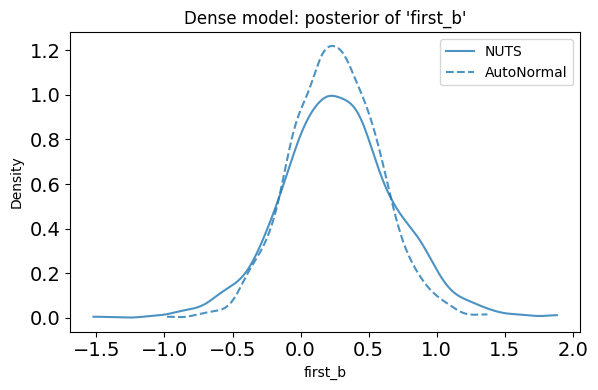

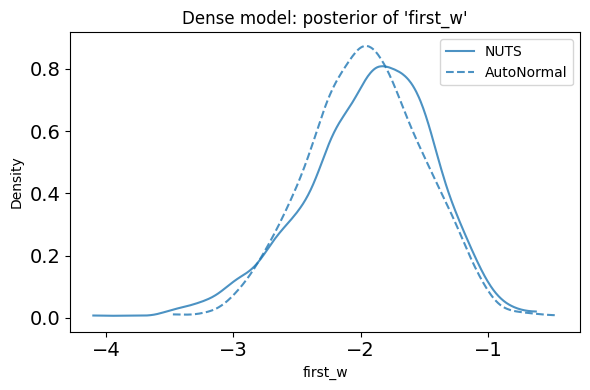

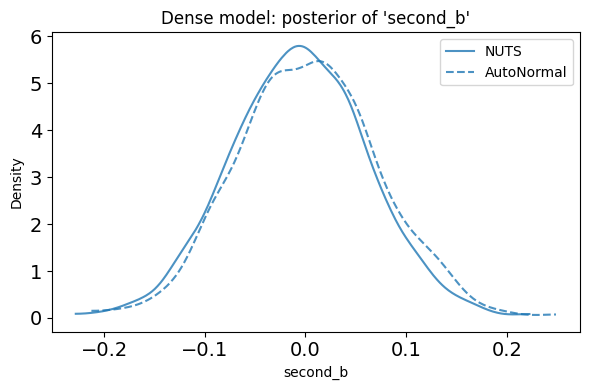

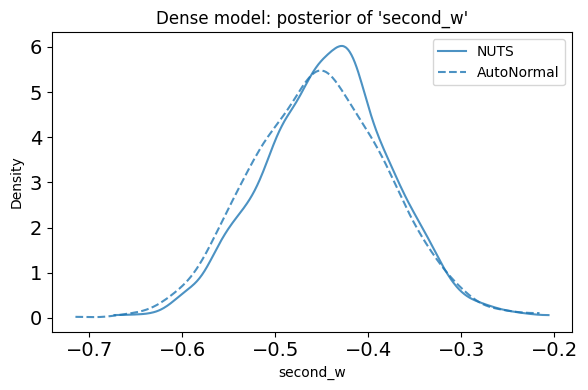

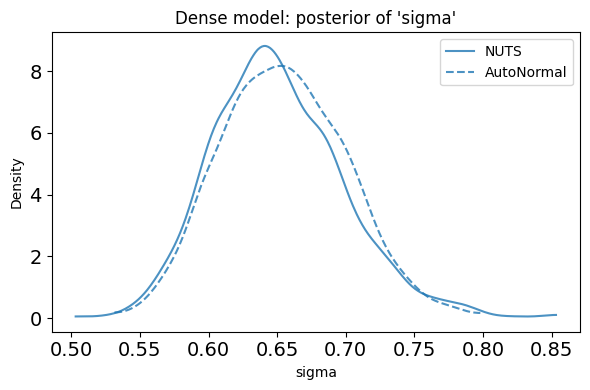

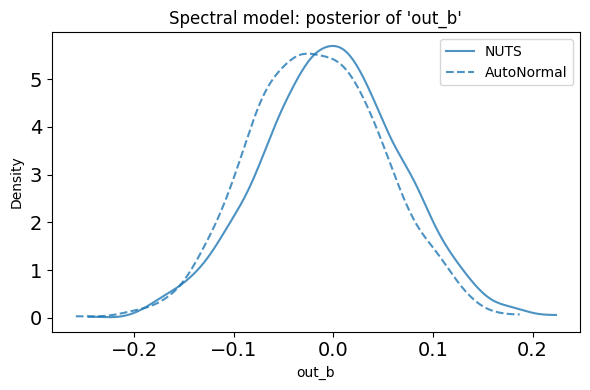

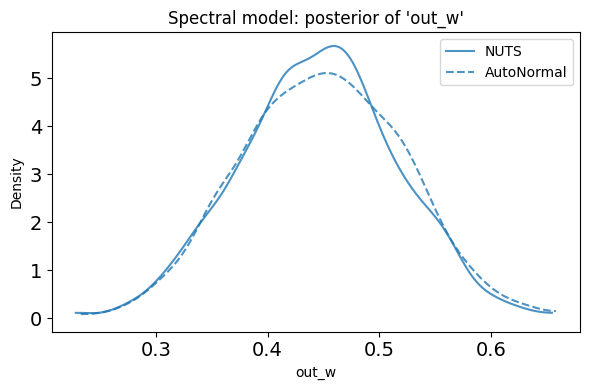

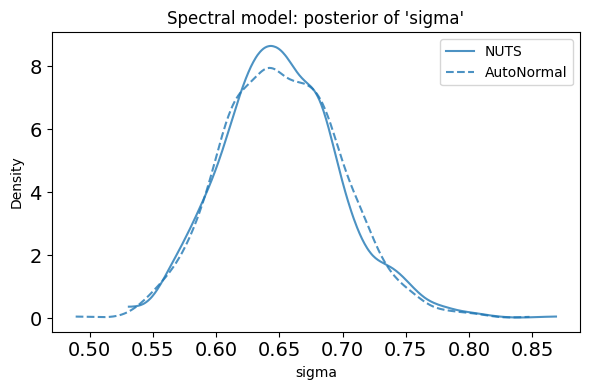

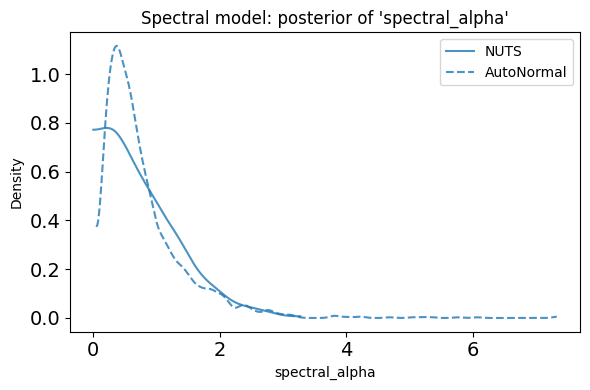

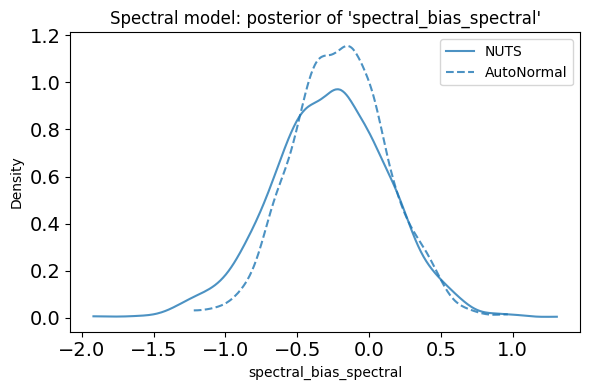

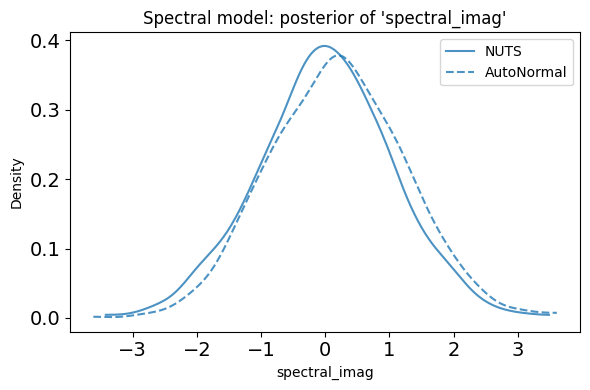

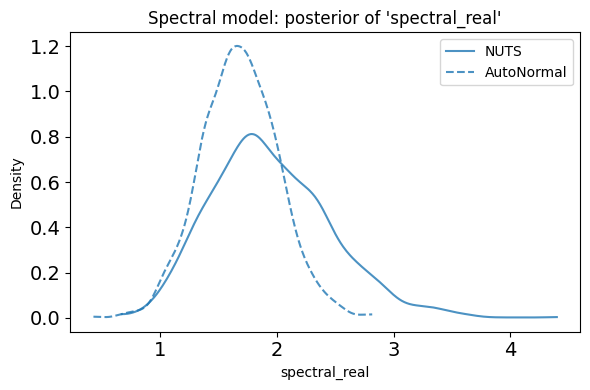

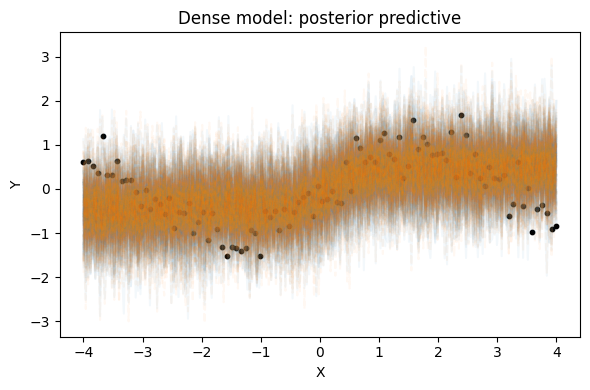

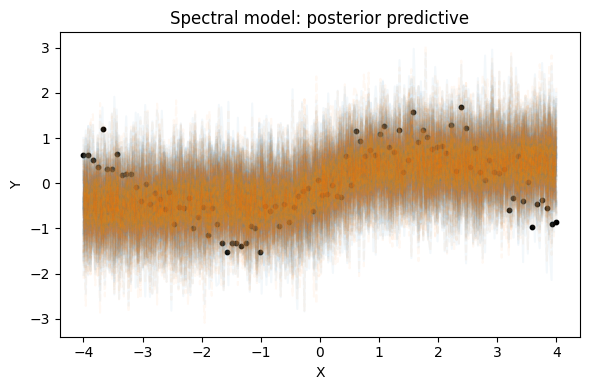

In [22]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import arviz as az
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from quantbayes import bnn  # provides Linear and SpectralCirculantLayer

# 1. Generate a slightly more challenging synthetic dataset
rng = jax.random.PRNGKey(42)
N = 100
X = np.linspace(-4, 4, N)[:, None]
Y = np.sin(X).squeeze() + 0.3 * np.random.randn(N)

# 2. Model definitions
def model_dense(X, Y=None):
    D = X.shape[1]
    h = jax.nn.tanh(bnn.Linear(D, D, name='first')(X))
    mean = bnn.Linear(D, 1, name='second')(h).squeeze()
    sigma = numpyro.sample('sigma', dist.Exponential(1.0))
    numpyro.sample('obs', dist.Normal(mean, sigma), obs=Y)

def model_spectral(X, Y=None):
    D = X.shape[1]
    # Use padded_dim = D so output dims match
    h = jax.nn.tanh(bnn.SpectralCirculantLayer(D, padded_dim=D, K=None, name='spectral')(X))
    mean = bnn.Linear(D, 1, name='out')(h).squeeze()
    sigma = numpyro.sample('sigma', dist.Exponential(1.0))
    numpyro.sample('obs', dist.Normal(mean, sigma), obs=Y)

# 3. Inference helpers
def run_nuts(model, X, Y, rng_key):
    mcmc = MCMC(NUTS(model), num_warmup=1000, num_samples=2000)
    mcmc.run(rng_key, X, Y)
    return mcmc.get_samples()

def run_svi(model, X, Y, rng_key):
    guide = AutoNormal(model)
    svi = SVI(model, guide, numpyro.optim.Adam(1e-2), Trace_ELBO())
    state = svi.init(rng_key, X, Y)
    result = svi.run(rng_key, 3000, X, Y, init_state=state)
    return guide.sample_posterior(rng_key, result.params, sample_shape=(2000,))

# 4. Fit both models
nuts = {
    'dense': run_nuts(model_dense, X, Y, rng),
    'spectral': run_nuts(model_spectral, X, Y, rng)
}
svi_samples = {
    'dense': run_svi(model_dense, X, Y, rng),
    'spectral': run_svi(model_spectral, X, Y, rng)
}

# 5. Plot per-site comparisons separately for each model
for model_name in ['dense', 'spectral']:
    sites = sorted(nuts[model_name].keys())
    for site in sites:
        arr_n = np.asarray(nuts[model_name][site])
        arr_s = np.asarray(svi_samples[model_name][site])
        plt.figure(figsize=(6, 4))
        az.plot_kde(arr_n, label='NUTS', plot_kwargs={'linestyle': '-', 'alpha': 0.8})
        az.plot_kde(arr_s, label='AutoNormal', plot_kwargs={'linestyle': '--', 'alpha': 0.8})
        plt.title(f"{model_name.title()} model: posterior of '{site}'")
        plt.xlabel(site)
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

# 6. Posterior-predictive overlay for each model
xs = np.linspace(-4, 4, 200)[:, None]
for model_name, model_fn in [('dense', model_dense), ('spectral', model_spectral)]:
    nuts_pred = Predictive(model_fn, nuts[model_name])(rng, xs)
    svi_pred  = Predictive(model_fn, svi_samples[model_name])(rng, xs)
    plt.figure(figsize=(6, 4))
    for i in range(100):
        plt.plot(xs, np.asarray(nuts_pred['obs'][i]), alpha=0.05, color='C0')
    for i in range(100):
        plt.plot(xs, np.asarray(svi_pred['obs'][i]), alpha=0.05, color='C1', linestyle='--')
    plt.scatter(X, Y, c='k', s=10)
    plt.title(f"{model_name.title()} model: posterior predictive")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.tight_layout()
    plt.show()


In [6]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

# (Optional) If you want to export static snapshots:
# pio.renderers.default = 'png'

# Filepaths for each of the three seeds per method
vanilla_paths = [
    "/Users/josephmargaryan/Downloads/losses_1.npy",
    "/Users/josephmargaryan/Downloads/losses_2.npy",
    "/Users/josephmargaryan/Downloads/losses_3.npy",
]
symm_paths = [
    "/Users/josephmargaryan/Desktop/results/losses/adaptive_spectral/AN/losses_1.npy",
    "/Users/josephmargaryan/Desktop/results/losses/adaptive_spectral/AN/losses_2.npy",
    "/Users/josephmargaryan/Desktop/results/losses/adaptive_spectral/AN/losses_3.npy",
]

def load_and_stack(paths):
    """Load each .npy under paths and stack into shape (n_seeds, n_steps)."""
    arrays = [np.load(p) for p in paths]
    return np.vstack(arrays)

def mean_and_ci(data, ci=0.95):
    """
    Given data shape (n_seeds, n_steps), compute per-step mean and
    mean ± z * (std/√n) for a normal-approx 95% CI.
    """
    mean = data.mean(axis=0)
    std  = data.std(axis=0, ddof=1)
    se   = std / np.sqrt(data.shape[0])
    z    = 1.96  # for 95% confidence
    lower = mean - z * se
    upper = mean + z * se
    return mean, lower, upper

# Load and compute stats
vanilla = load_and_stack(vanilla_paths)
symm    = load_and_stack(symm_paths)

van_mean, van_lo, van_hi = mean_and_ci(vanilla)
symm_mean, symm_lo, symm_hi = mean_and_ci(symm)

# X-axis (training steps)
steps = np.arange(1, van_mean.shape[0] + 1)

# Build figure
fig = go.Figure()

# --- Vanilla AutoNormal (mean + CI) ---
fig.add_trace(go.Scatter(
    x=steps, y=van_mean,
    mode='lines',
    name='SpectralCirc + Vanilla AutoNormal (mean)',
    line=dict(width=3)
))
fig.add_trace(go.Scatter(
    x=steps, y=van_hi,
    mode='lines',
    showlegend=False,
    line=dict(width=0),
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=steps, y=van_lo,
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(0,100,200,0.2)',
    name='±95% CI'
))

# --- Adaptive Spectral + Custom Guide (mean + CI) ---
fig.add_trace(go.Scatter(
    x=steps, y=symm_mean,
    mode='lines',
    name='AdaptiveSpecCirc + Custom Guide (mean)',
    line=dict(width=3, dash='dash')
))
fig.add_trace(go.Scatter(
    x=steps, y=symm_hi,
    mode='lines',
    showlegend=False,
    line=dict(width=0),
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=steps, y=symm_lo,
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(200,50,50,0.2)',
    name='±95% CI'
))

# Layout and log-scale Y axis
fig.update_layout(
    template='simple_white',
    title='ELBO over Training Steps\n(mean ± 95% CI across 3 seeds)',
    title_font_size=20,
    xaxis_title='Training Step',
    yaxis_title='ELBO',
    font=dict(size=16),
    legend=dict(title='Method', font=dict(size=14)),
    width=800,
    height=600
)
fig.update_yaxes(type='log')

# Render
fig.show()


In [ ]:

import jax, jax.numpy as jnp
from jax import custom_jvp
import equinox as eqx
import jax.random as jr
from typing import Optional


# -----------------------------------------------------------------------------#
@custom_jvp
def circulant_conv2d_fft(kernel: jnp.ndarray, x: jnp.ndarray) -> jnp.ndarray:
    """
    kernel : (C_out, C_in, H_pad, W_pad)   real
    x      : (..., C_in,  H_in,  W_in)     real
    returns: (..., C_out, H_pad, W_pad)    real
    """
    C_out, C_in, H_pad, W_pad = kernel.shape
    single = x.ndim == 3
    if single:
        x = x[None, ...]
    *lead, C_in_x, H_in, W_in = x.shape
    if C_in_x != C_in:
        raise ValueError(f"Cin mismatch: kernel={C_in}, x={C_in_x}")

    pad_h, pad_w = max(0, H_pad - H_in), max(0, W_pad - W_in)
    x_pad = jnp.pad(x, ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]

    # rfft2 saves ~½ memory for real inputs; XLA will choose cuFFT plan
    Kf = jnp.fft.rfftn(kernel, axes=(-2, -1))
    Xf = jnp.fft.rfftn(x_pad, axes=(-2, -1))
    Yf = jnp.einsum("oihw,bihw->bohw", Kf, Xf)
    y  = jnp.fft.irfftn(Yf, s=(H_pad, W_pad), axes=(-2, -1))
    return y[0] if single else y


@circulant_conv2d_fft.defjvp
def _circulant_conv2d_fft_jvp(primals, tangents):
    kernel, x = primals
    dk, dx    = tangents

    C_out, C_in, H_pad, W_pad = kernel.shape
    single = x.ndim == 3
    if single:
        x  = x[None, ...]
        dx = None if dx is None else dx[None, ...]

    pad_h, pad_w = max(0, H_pad - x.shape[-2]), max(0, W_pad - x.shape[-1])
    x_pad  = jnp.pad(x,  ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]
    dx_pad = None
    if dx is not None:
        dx_pad = jnp.pad(dx, ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]

    Kf  = jnp.fft.rfftn(kernel, axes=(-2, -1))
    Xf  = jnp.fft.rfftn(x_pad, axes=(-2, -1))
    Yf  = jnp.einsum("oihw,bihw->bohw", Kf, Xf)
    y   = jnp.fft.irfftn(Yf, s=(H_pad, W_pad), axes=(-2, -1))

    dKf = jnp.fft.rfftn(dk, axes=(-2, -1)) if dk is not None else 0.0
    dXf = jnp.fft.rfftn(dx_pad, axes=(-2, -1)) if dx_pad is not None else 0.0
    dYf = (jnp.einsum("oihw,bihw->bohw", dKf, Xf) +
           jnp.einsum("oihw,bihw->bohw", Kf, dXf))
    dy  = jnp.fft.irfftn(dYf, s=(H_pad, W_pad), axes=(-2, -1))

    if single:
        y, dy = y[0], dy[0]
    return y, dy


# -----------------------------------------------------------------------------#
class Circulant2d(eqx.Module):
    """Real weight-space wrap-around convolution."""

    kernel: jnp.ndarray     
    bias:   jnp.ndarray    
    C_in:   int = eqx.static_field()
    C_out:  int = eqx.static_field()
    H_pad:  int = eqx.static_field()
    W_pad:  int = eqx.static_field()

    def __init__(
        self,
        C_in: int,
        C_out: int,
        H_in: int,
        W_in: int,
        *,
        H_pad: Optional[int] = None,
        W_pad: Optional[int] = None,
        key,
        init_scale: float = 1.0,
        bias_scale: float = 1.0,
        dtype=jnp.float32,
    ):
        self.C_in, self.C_out = C_in, C_out
        self.H_pad = int(H_pad or H_in)
        self.W_pad = int(W_pad or W_in)

        k1, k2 = jr.split(key, 2)
        self.kernel = (jr.normal(
            k1, (C_out, C_in, self.H_pad, self.W_pad), dtype
        ) * init_scale).astype(dtype)
        self.bias = (jr.normal(
            k2, (C_out, self.H_pad, self.W_pad), dtype
        ) * bias_scale).astype(dtype)

    def get_kernel(self) -> jnp.ndarray:
        """Return spatial (real) kernel for logging / saving."""
        return self.kernel

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        y = circulant_conv2d_fft(self.kernel, x)
        return y + (self.bias if y.ndim == 3 else self.bias[None, :])
    
if __name__ == "__main__":
    import jax.random as jr
    import jax.numpy as jnp

 
    x = jr.normal(jr.PRNGKey(0), (4, 3, 32, 32))


    layer = Circulant2d(
        C_in=3,
        C_out=16,
        H_in=32,
        W_in=32,
        key=jr.PRNGKey(1),
    )

    # forward pass
    y = layer(x)

    # check output shapes
    print("y.shape:", y.shape)                   # should be (4, 16, 32, 32)
    print("kernel.shape:", layer.get_kernel().shape)  # should be (16, 3, 32, 32)




y.shape: (4, 16, 32, 32)
kernel.shape: (16, 3, 32, 32)


In [ ]:
# equinox_spectral_circulant2d.py
# -----------------------------------------------------------------------------#
#  Spectral circulant 2-D CONVOLUTION (Cin → Cout)  —  Equinox implementation  #
# -----------------------------------------------------------------------------#
#
#  y(b, Cout, H, W)  =  IFFT2(  FFT2(x)  ∘  FFT_kernel(Cout,Cin,H,W)  )
#
#  * Hermitian symmetry is enforced channel-wise so the spatial weights remain
#    strictly real.  The layer therefore works for either deterministic SGD
#    or probabilistic (NumPyro) settings.
#
#  Author: 2025-07-02
# -----------------------------------------------------------------------------#
import jax
import jax.numpy as jnp
from jax import custom_jvp
import equinox as eqx
import jax.random as jr
from typing import Optional


def _enforce_hermitian(fft2d: jnp.ndarray) -> jnp.ndarray:
    """
    Project complex tensor (..., H, W) onto the Hermitian subspace so that the
    spatial inverse FFT yields a real array.

    Works on an arbitrary leading batch / channel shape; only the last two axes
    are treated as frequency dimensions.
    """
    H, W = fft2d.shape[-2:]
    conj_flip = jnp.flip(jnp.conj(fft2d), axis=(-2, -1))
    herm = 0.5 * (fft2d + conj_flip)                    

    herm = herm.at[..., 0, 0].set(jnp.real(herm[..., 0, 0]))
    if H % 2 == 0:
        herm = herm.at[..., H // 2, :].set(jnp.real(herm[..., H // 2, :]))
    if W % 2 == 0:
        herm = herm.at[..., :, W // 2].set(jnp.real(herm[..., :, W // 2]))
    return herm


@custom_jvp
def spectral_circulant_conv2d(x: jnp.ndarray, fft_kernel: jnp.ndarray) -> jnp.ndarray:
    """
    Circular (wrap-around) convolution via direct multiplication in
    Fourier space.

        fft_kernel : (C_out, C_in, H_pad, W_pad)   — complex Hermitian
        x          : (..., C_in, H_in,  W_in)      — real
        returns    : (..., C_out, H_pad, W_pad)    — real
    """
    C_out, C_in, H_pad, W_pad = fft_kernel.shape
    single = x.ndim == 3                            
    if single:
        x = x[None, ...]                          

    *lead, C_in_x, H_in, W_in = x.shape
    if C_in_x != C_in:
        raise ValueError(f"Cin mismatch: kernel={C_in}, x={C_in_x}")

    pad_h, pad_w = max(0, H_pad - H_in), max(0, W_pad - W_in)
    x_pad = jnp.pad(x, ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))
    x_pad = x_pad[..., :H_pad, :W_pad]

    Xf = jnp.fft.fftn(x_pad, axes=(-2, -1))                       
    Yf = jnp.einsum("oihw,bihw->bohw", fft_kernel, Xf)         
    y  = jnp.fft.ifftn(Yf, axes=(-2, -1)).real

    if single:
        y = y[0]                                         
    return y


@spectral_circulant_conv2d.defjvp
def _spectral_circulant_conv2d_jvp(primals, tangents):
    x, fft_kernel = primals
    dx, dk        = tangents               

    C_out, C_in, H_pad, W_pad = fft_kernel.shape
    single = x.ndim == 3
    if single:
        x  = x[None, ...]
        dx = None if dx is None else dx[None, ...]

    pad_h, pad_w = max(0, H_pad - x.shape[-2]), max(0, W_pad - x.shape[-1])
    x_pad  = jnp.pad(x,  ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]
    dx_pad = None
    if dx is not None:
        dx_pad = jnp.pad(dx, ((0, 0), (0, 0), (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]

    Xf  = jnp.fft.fftn(x_pad, axes=(-2, -1))
    Yf  = jnp.einsum("oihw,bihw->bohw", fft_kernel, Xf)
    y   = jnp.fft.ifftn(Yf, axes=(-2, -1)).real

    dKf = jnp.fft.fftn(dk, axes=(-2, -1)) if dk is not None else 0.0
    dXf = jnp.fft.fftn(dx_pad, axes=(-2, -1)) if dx_pad is not None else 0.0
    dYf = (jnp.einsum("oihw,bihw->bohw", dKf, Xf) +
           jnp.einsum("oihw,bihw->bohw", fft_kernel, dXf))
    dy  = jnp.fft.ifftn(dYf, axes=(-2, -1)).real

    if single:
        y, dy = y[0], dy[0]
    return y, dy

class SpectralCirculant2d(eqx.Module):
    """
    **Deterministic** spectral circulant layer ready for production use.

    Parameters
    ----------
    C_in, C_out : int
        Input / output channels.
    H_in, W_in  : int
        Input spatial resolution.
    H_pad, W_pad: int, optional
        Output resolution after wrap-around padding (defaults to H_in/W_in).
    alpha_init  : float
        Initial power-law decay exponent (controls smoothness).
    key         : jax.random.PRNGKey
        RNG for parameter initialisation.
    init_scale, bias_scale : float
        Std-dev multipliers for weight / bias initialisation.
    dtype       : jnp.dtype
        Parameter dtype (default float32).
    """

    alpha:  jnp.ndarray            
    w_real: jnp.ndarray            
    w_imag: jnp.ndarray            
    bias:   jnp.ndarray             

    H_pad: int = eqx.static_field()
    W_pad: int = eqx.static_field()

    def __init__(
        self,
        C_in: int,
        C_out: int,
        H_in: int,
        W_in: int,
        *,
        H_pad: Optional[int] = None,
        W_pad: Optional[int] = None,
        alpha_init: float = 1.0,
        key,
        init_scale: float = 0.1,
        bias_scale: float = 0.1,
        dtype=jnp.float32,
    ):
        self.H_pad = int(H_pad or H_in)
        self.W_pad = int(W_pad or W_in)
        self.alpha = jnp.asarray(alpha_init, dtype)

        u = jnp.fft.fftfreq(self.H_pad, dtype=dtype) * self.H_pad
        v = jnp.fft.fftfreq(self.W_pad, dtype=dtype) * self.W_pad
        U, V = jnp.meshgrid(u, v, indexing="ij")
        R = jnp.sqrt(U**2 + V**2)
        std0 = 1.0 / jnp.sqrt(1.0 + R**alpha_init)    
        std0 = std0[None, None, :, :]          

        k_r, k_i, k_b = jr.split(key, 3)
        self.w_real = jr.normal(
            k_r, (C_out, C_in, self.H_pad, self.W_pad), dtype
        ) * (init_scale * std0)
        wi = jr.normal(k_i, (C_out, C_in, self.H_pad, self.W_pad), dtype) * (init_scale * std0)
        wi = wi.at[..., 0, 0].set(0.0)
        if self.H_pad % 2 == 0:
            wi = wi.at[..., self.H_pad // 2, :].set(0.0)
        if self.W_pad % 2 == 0:
            wi = wi.at[..., :, self.W_pad // 2].set(0.0)
        self.w_imag = wi
        self.bias = jr.normal(
            k_b, (C_out, self.H_pad, self.W_pad), dtype
        ) * bias_scale

    def get_fft_kernel(self) -> jnp.ndarray:
        """Return complex Hermitian FFT kernel (useful for visualisation)."""
        return _enforce_hermitian(self.w_real + 1j * self.w_imag)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """
        x : (..., C_in, H_in, W_in)
        returns (..., C_out, H_pad, W_pad)
        """
        fft_kernel = self.get_fft_kernel()                    
        y = spectral_circulant_conv2d(x, fft_kernel)          
        if y.ndim == 3:
            return y + self.bias
        else:
            return y + self.bias[None, :]                    
        

if __name__ == "__main__":
    import jax.numpy as jnp, jax.random as jr, equinox as eqx

    x = jr.normal(jr.PRNGKey(0), (4, 3, 32, 32))  
    layer = SpectralCirculant2d(
        C_in=3,
        C_out=16,
        H_in=32,
        W_in=32,
        H_pad=32,  
        W_pad=32,
        key=jr.PRNGKey(1),
    )

    y = layer(x)                                  
    print(y.shape)
    print(layer.get_fft_kernel().shape)           


(4, 16, 32, 32)
(16, 3, 32, 32)


In [ ]:

import jax
import jax.numpy as jnp
from jax import custom_jvp
import numpyro
import numpyro.distributions as dist
from typing import Optional, Callable, Tuple


def _enforce_hermitian(fft2d: jnp.ndarray) -> jnp.ndarray:
    """Project (..., H, W) complex tensor onto Hermitian subspace."""
    H, W = fft2d.shape[-2:]
    conj_flip = jnp.flip(jnp.conj(fft2d), axis=(-2, -1))
    herm = 0.5 * (fft2d + conj_flip)
    herm = herm.at[..., 0, 0].set(jnp.real(herm[..., 0, 0]))
    if H % 2 == 0:
        herm = herm.at[..., H // 2, :].set(jnp.real(herm[..., H // 2, :]))
    if W % 2 == 0:
        herm = herm.at[..., :, W // 2].set(jnp.real(herm[..., :, W // 2]))
    return herm

@custom_jvp
def fft_conv2d_real(kernel: jnp.ndarray, x: jnp.ndarray) -> jnp.ndarray:
    """
    Circular 2-D convolution with real weights via rFFT.

      kernel : (C_out, C_in, H_pad, W_pad)  real
      x      : (..., C_in,  H_in,  W_in)    real
      ->       (..., C_out, H_pad, W_pad)   real
    """
    C_out, C_in, H_pad, W_pad = kernel.shape
    single = x.ndim == 3
    if single:
        x = x[None, ...]
    *lead, C_in_x, H_in, W_in = x.shape
    if C_in_x != C_in:
        raise ValueError(f"Cin mismatch (kernel={C_in}, x={C_in_x})")

    pad_h, pad_w = max(0, H_pad - H_in), max(0, W_pad - W_in)
    x_pad = jnp.pad(x, ((0, 0), (0, 0),
                        (0, pad_h), (0, pad_w)))[..., :H_pad, :W_pad]

    Kf = jnp.fft.rfftn(kernel, axes=(-2, -1))              
    Xf = jnp.fft.rfftn(x_pad, axes=(-2, -1))                
    Yf = jnp.einsum("oihw,bihw->bohw", Kf, Xf)
    y  = jnp.fft.irfftn(Yf, s=(H_pad, W_pad), axes=(-2, -1))
    return y[0] if single else y


@fft_conv2d_real.defjvp
def _fft_conv2d_real_jvp(primals, tangents):
    kernel, x = primals
    dk, dx    = tangents

    C_out, C_in, H_pad, W_pad = kernel.shape
    single = x.ndim == 3
    if single:
        x  = x[None, ...]
        dx = None if dx is None else dx[None, ...]

    pad_h, pad_w = max(0, H_pad - x.shape[-2]), max(0, W_pad - x.shape[-1])
    x_pad  = jnp.pad(x,  ((0,0),(0,0),(0,pad_h),(0,pad_w)))[..., :H_pad, :W_pad]
    dx_pad = None
    if dx is not None:
        dx_pad = jnp.pad(dx, ((0,0),(0,0),(0,pad_h),(0,pad_w)))[..., :H_pad, :W_pad]

    Kf  = jnp.fft.rfftn(kernel, axes=(-2,-1))
    Xf  = jnp.fft.rfftn(x_pad, axes=(-2,-1))
    Yf  = jnp.einsum("oihw,bihw->bohw", Kf, Xf)
    y   = jnp.fft.irfftn(Yf, s=(H_pad,W_pad), axes=(-2,-1))

    dKf = jnp.fft.rfftn(dk, axes=(-2,-1)) if dk is not None else 0.0
    dXf = jnp.fft.rfftn(dx_pad, axes=(-2,-1)) if dx_pad is not None else 0.0
    dYf = (jnp.einsum("oihw,bihw->bohw", dKf, Xf) +
           jnp.einsum("oihw,bihw->bohw", Kf, dXf))
    dy  = jnp.fft.irfftn(dYf, s=(H_pad,W_pad), axes=(-2,-1))
    if single:
        y, dy = y[0], dy[0]
    return y, dy


class Circulant2d:
    """Real weight-space circulant convolution (Bayesian or deterministic)."""

    C_in:  int
    C_out: int
    H_pad: int
    W_pad: int
    dtype: jnp.dtype

    def __init__(
        self,
        C_in: int,
        C_out: int,
        H_in: int,
        W_in: int,
        *,
        H_pad: Optional[int] = None,
        W_pad: Optional[int] = None,
        name: str = "circ2d",
        kernel_prior_fn=lambda shape, dtype: dist.Normal(0, 1).expand(shape).to_event(4),
        bias_prior_fn=lambda shape, dtype: dist.Normal(0, 1).expand(shape).to_event(3),
        dtype=jnp.float32,
    ):
        self.C_in, self.C_out = C_in, C_out
        self.H_pad = H_pad or H_in
        self.W_pad = W_pad or W_in
        self.dtype = dtype
        self.name  = name
        self._kernel_prior_fn = kernel_prior_fn
        self._bias_prior_fn   = bias_prior_fn

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        kernel = numpyro.sample(
            f"{self.name}_kernel",
            self._kernel_prior_fn(
                (self.C_out, self.C_in, self.H_pad, self.W_pad), self.dtype
            ),
        )
        bias = numpyro.sample(
            f"{self.name}_bias",
            self._bias_prior_fn((self.C_out, self.H_pad, self.W_pad), self.dtype),
        )

        y = fft_conv2d_real(kernel.astype(x.dtype), x)
        return y + (bias if y.ndim == 3 else bias[None, :])

    def get_kernel(self, params) -> jnp.ndarray:
        """Extract spatial kernel from a NumPyro param dict after fitting."""
        return params[f"{self.name}_kernel"]


@custom_jvp
def spectral_circulant_conv2d(
    x: jnp.ndarray, fft_kernel: jnp.ndarray
) -> jnp.ndarray:
    """
    fft_kernel : (C_out, C_in, H_pad, W_pad)  complex Hermitian
    x          : (..., C_in, H_in, W_in)      real
    """
    C_out, C_in, H_pad, W_pad = fft_kernel.shape
    single = x.ndim == 3
    if single:
        x = x[None, ...]
    *lead, C_in_x, H_in, W_in = x.shape
    if C_in_x != C_in:
        raise ValueError("Cin mismatch.")

    pad_h, pad_w = max(0, H_pad - H_in), max(0, W_pad - W_in)
    x_pad = jnp.pad(x, ((0,0),(0,0),(0,pad_h),(0,pad_w)))[..., :H_pad, :W_pad]

    Xf = jnp.fft.fftn(x_pad, axes=(-2, -1))
    Yf = jnp.einsum("oihw,bihw->bohw", fft_kernel, Xf)
    y  = jnp.fft.ifftn(Yf, axes=(-2, -1)).real
    return y[0] if single else y


@spectral_circulant_conv2d.defjvp
def _spectral_circulant_conv2d_jvp(primals, tangents):
    x, fft_kernel = primals
    dx, dk        = tangents

    C_out, C_in, H_pad, W_pad = fft_kernel.shape
    single = x.ndim == 3
    if single:
        x  = x[None, ...]
        dx = None if dx is None else dx[None, ...]

    pad_h, pad_w = max(0, H_pad - x.shape[-2]), max(0, W_pad - x.shape[-1])
    x_pad  = jnp.pad(x,  ((0,0),(0,0),(0,pad_h),(0,pad_w)))[..., :H_pad, :W_pad]
    dx_pad = None
    if dx is not None:
        dx_pad = jnp.pad(dx, ((0,0),(0,0),(0,pad_h),(0,pad_w)))[..., :H_pad, :W_pad]

    Xf  = jnp.fft.fftn(x_pad, axes=(-2, -1))
    Yf  = jnp.einsum("oihw,bihw->bohw", fft_kernel, Xf)
    y   = jnp.fft.ifftn(Yf, axes=(-2, -1)).real

    dKf = jnp.fft.fftn(dk, axes=(-2, -1)) if dk is not None else 0.0
    dXf = jnp.fft.fftn(dx_pad, axes=(-2, -1)) if dx_pad is not None else 0.0
    dYf = (jnp.einsum("oihw,bihw->bohw", dKf, Xf) +
           jnp.einsum("oihw,bihw->bohw", fft_kernel, dXf))
    dy  = jnp.fft.ifftn(dYf, axes=(-2, -1)).real
    if single:
        y, dy = y[0], dy[0]
    return y, dy


class SpectralCirculantLayer2d:
    """
    GP-origin spectral layer with *fixed* α (shared across channels).
    """

    def __init__(
        self,
        C_in: int,
        C_out: int,
        H_in: int,
        W_in: int,
        *,
        H_pad: Optional[int] = None,
        W_pad: Optional[int] = None,
        alpha: Optional[float] = None,
        alpha_prior: dist.Distribution = dist.HalfNormal(1.0),
        name: str = "spec2d",
        prior_fn: Optional[Callable[[jnp.ndarray], dist.Distribution]] = None,
        dtype=jnp.float32,
    ):
        self.C_in, self.C_out = C_in, C_out
        self.H_pad = H_pad or H_in
        self.W_pad = W_pad or W_in
        self.alpha = alpha
        self.alpha_prior = alpha_prior
        self.name = name
        self.dtype = dtype
        self._prior_fn = prior_fn or (lambda scale: dist.Normal(0, scale))

        self._fft_kernel = None   

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        α = (
            self.alpha
            if self.alpha is not None
            else numpyro.sample(f"{self.name}_alpha", self.alpha_prior)
        )

        u = jnp.fft.fftfreq(self.H_pad, dtype=self.dtype) * self.H_pad
        v = jnp.fft.fftfreq(self.W_pad, dtype=self.dtype) * self.W_pad
        U, V = jnp.meshgrid(u, v, indexing="ij")
        R    = jnp.sqrt(U**2 + V**2)
        std  = (1.0 / jnp.sqrt(1.0 + R**α)).astype(self.dtype)   
        std  = std[None, None, :, :]                             

        real = numpyro.sample(
            f"{self.name}_real",
            self._prior_fn(std).expand(
                (self.C_out, self.C_in, self.H_pad, self.W_pad)
            ).to_event(4),
        )
        imag = numpyro.sample(
            f"{self.name}_imag",
            self._prior_fn(std).expand(
                (self.C_out, self.C_in, self.H_pad, self.W_pad)
            ).to_event(4),
        )

        fft_kernel = _enforce_hermitian(real + 1j * imag)
        self._fft_kernel = jax.lax.stop_gradient(fft_kernel)

        bias = numpyro.sample(
            f"{self.name}_bias",
            dist.Normal(0, 1)
                .expand((self.C_out, self.H_pad, self.W_pad))
                .to_event(3),
        )

        y = spectral_circulant_conv2d(x, fft_kernel)
        return y + (bias if y.ndim == 3 else bias[None, :])

    def get_fft_kernel(self):
        if self._fft_kernel is None:
            raise RuntimeError("Call the layer once to instantiate weights.")
        return self._fft_kernel


class AdaptiveSpectralCirculantLayer2d(SpectralCirculantLayer2d):
    """
    Adaptive version with a **learned per-frequency α(u,v)** map
    (via coarse HalfNormal residual grid).
    """

    def __init__(
        self,
        C_in: int,
        C_out: int,
        H_in: int,
        W_in: int,
        *,
        H_pad: Optional[int] = None,
        W_pad: Optional[int] = None,
        alpha_global: float = 1.0,
        alpha_coarse_shape: Tuple[int, int] = (8, 8),
        alpha_prior: dist.Distribution = dist.HalfNormal(1.0),
        name: str = "adap_spec2d",
        prior_fn: Optional[Callable[[jnp.ndarray], dist.Distribution]] = None,
        dtype=jnp.float32,
    ):
        super().__init__(
            C_in, C_out, H_in, W_in,
            H_pad=H_pad, W_pad=W_pad,
            alpha=None,
            alpha_prior=alpha_prior,
            name=name,
            prior_fn=prior_fn,
            dtype=dtype,
        )
        self.alpha_global = alpha_global
        self.alpha_coarse_shape = alpha_coarse_shape
        self._m = jnp.log(jnp.exp(5.0 - 0.1) - 1.0)   
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        delta_alpha_coarse = numpyro.sample(
            f"{self.name}_delta_alpha",
            self.alpha_prior.expand(self.alpha_coarse_shape).to_event(2),
        )

        gh, gw = self.alpha_coarse_shape
        y_lin = jnp.linspace(0.0, 1.0, self.H_pad)
        x_lin = jnp.linspace(0.0, 1.0, self.W_pad)
        yy, xx = jnp.meshgrid(y_lin, x_lin, indexing="ij")
        yy = yy * (gh - 1)
        xx = xx * (gw - 1)
        y0, x0 = jnp.floor(yy).astype(int), jnp.floor(xx).astype(int)
        y1, x1 = jnp.clip(y0 + 1, 0, gh - 1), jnp.clip(x0 + 1, 0, gw - 1)
        wy, wx = yy - y0, xx - x0
        d_full = (
            (1 - wy) * ((1 - wx) * delta_alpha_coarse[y0, x0] +
                        wx * delta_alpha_coarse[y0, x1]) +
            wy       * ((1 - wx) * delta_alpha_coarse[y1, x0] +
                        wx * delta_alpha_coarse[y1, x1])
        )

        raw_alpha = self.alpha_global + d_full
        alpha_map = 0.1 + jax.nn.softplus(raw_alpha - self._m)  
        std  = 1.0 / jnp.sqrt(1.0 + (jnp.fft.fftfreq(self.H_pad)[:,None]**2 +
                                     jnp.fft.fftfreq(self.W_pad)[None,:]**2
                                     )**(alpha_map/2))
        std  = std.astype(self.dtype)[None, None, :, :]   

        real = numpyro.sample(
            f"{self.name}_real",
            self._prior_fn(std).expand(
                (self.C_out, self.C_in, self.H_pad, self.W_pad)
            ).to_event(4),
        )
        imag = numpyro.sample(
            f"{self.name}_imag",
            self._prior_fn(std).expand(
                (self.C_out, self.C_in, self.H_pad, self.W_pad)
            ).to_event(4),
        )

        fft_kernel = _enforce_hermitian(real + 1j * imag)
        self._fft_kernel = jax.lax.stop_gradient(fft_kernel)

        bias = numpyro.sample(
            f"{self.name}_bias",
            dist.Normal(0, 1)
                .expand((self.C_out, self.H_pad, self.W_pad))
                .to_event(3),
        )

        y = spectral_circulant_conv2d(x, fft_kernel)
        return y + (bias if y.ndim == 3 else bias[None, :])


import jax.random as jr, jax.numpy as jnp, numpyro
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam

def model(x, y=None):
    layer = SpectralCirculantLayer2d(C_in=3, C_out=16,
                                     H_in=32, W_in=32,
                                     name="spec32")
    logits = layer(x).mean((-2, -1))   
    numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

x_dummy = jr.normal(jr.PRNGKey(0), (8, 3, 32, 32))
y_dummy = jnp.zeros((8,), dtype=jnp.int32)

guide = AutoNormal(model)
optim = Adam(1e-3)
svi = SVI(model, guide, optim, Trace_ELBO())

state = svi.init(jr.PRNGKey(1), x_dummy, y_dummy)
state, loss = svi.update(state, x_dummy, y_dummy)
print("ELBO", loss)


ELBO 3699755000.0


In [ ]:

import math
import jax, jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer.autoguide import AutoGuide


def halfplane_to_full_multi(real_hp, imag_hp, H_pad, W_pad):
    """
    real_hp, imag_hp : (..., H_pad, W_half)
       leading dims may be (C_out, C_in) or batch.
    Returns complex Hermitian (..., H_pad, W_pad) array.
    """
    W_half = real_hp.shape[-1]
    full = jnp.zeros(real_hp.shape[:-1] + (W_pad,), dtype=real_hp.dtype) + 0j
    full = full.at[..., :W_half].set(real_hp + 1j * imag_hp) 

    full = _enforce_hermitian(full)
    return full.real, full.imag


class LowRankFFTGuide2dCh(AutoGuide):
    """
    Low-rank Gaussian guide over the **entire channelled half-plane**:
        real_hp : (C_out, C_in, H_pad, W_half)
        imag_hp : same
    """

    def __init__(
        self,
        model,
        prefix: str,
        C_out: int,
        C_in: int,
        H_pad: int,
        W_pad: int,
        rank: int = 8,
        jitter: float = 1e-4,
    ):
        super().__init__(model)
        self.prefix = prefix
        self.C_out, self.C_in = C_out, C_in
        self.H_pad, self.W_pad = H_pad, W_pad
        self.W_half = W_pad // 2 + 1
        self.M = C_out * C_in * H_pad * self.W_half       
        self.rank = rank
        self.jitter = jitter
        self.joint = f"{prefix}_joint"

    def _build_lowrank(self):
        dim = 2 * self.M
        loc  = numpyro.param(f"{self.joint}_loc", jnp.zeros(dim))
        V    = numpyro.param(
            f"{self.joint}_V",
            0.05 * jax.random.normal(numpyro.prng_key(), (dim, self.rank))
            / math.sqrt(dim),
        )
        d_raw   = numpyro.param(f"{self.joint}_d_raw", jnp.zeros(dim))
        log_tau = numpyro.param(f"{self.joint}_log_tau", jnp.array(0.0))
        diag = jax.nn.softplus(d_raw) * jnp.exp(log_tau) + self.jitter
        cov  = V @ V.T + jnp.diag(diag)

        return numpyro.sample(
            self.joint,
            dist.MultivariateNormal(loc, covariance_matrix=cov),
            infer={"is_auxiliary": True},
        )

    def __call__(self, *args, **kwargs):
        z = self._build_lowrank()                     

        real_hp, imag_hp = jnp.split(z, 2, axis=-1)     
        shape_hp = (self.C_out, self.C_in, self.H_pad, self.W_half)
        real_hp  = real_hp.reshape(shape_hp)
        imag_hp  = imag_hp.reshape(shape_hp)

        r_full, i_full = halfplane_to_full_multi(
            real_hp, imag_hp, self.H_pad, self.W_pad
        )

        numpyro.sample(
            f"{self.prefix}_real",
            dist.Delta(r_full).to_event(4),
        )
        numpyro.sample(
            f"{self.prefix}_imag",
            dist.Delta(i_full).to_event(4),
        )

        return {f"{self.prefix}_real": r_full,
                f"{self.prefix}_imag": i_full}

    def sample_posterior(self, rng_key, params, sample_shape=()):
        dim = 2 * self.M
        loc   = params[f"{self.joint}_loc"]
        V     = params[f"{self.joint}_V"]
        d_raw = params[f"{self.joint}_d_raw"]
        ltau  = params[f"{self.joint}_log_tau"]
        diag  = jax.nn.softplus(d_raw) * jnp.exp(ltau) + self.jitter
        cov   = V @ V.T + jnp.diag(diag)

        mvn = dist.MultivariateNormal(loc, covariance_matrix=cov)
        z   = mvn.sample(rng_key, sample_shape)                
        real_hp, imag_hp = jnp.split(z, 2, axis=-1)

        shape_hp = sample_shape + (
            self.C_out, self.C_in, self.H_pad, self.W_half
        )
        real_hp = real_hp.reshape(shape_hp)
        imag_hp = imag_hp.reshape(shape_hp)

        r_full, i_full = jax.vmap(
            lambda r, i: halfplane_to_full_multi(r, i, self.H_pad, self.W_pad),
            in_axes=0,
        )(real_hp, imag_hp)

        return {f"{self.prefix}_real": r_full,
                f"{self.prefix}_imag": i_full}


class LowRankAdaptiveFFTGuide2dCh(AutoGuide):
    """
    Joint low-rank guide over:
        - Δα coarse grid  (gh,gw)
        - multi-channel half-plane fourier coeffs
    """

    def __init__(
        self,
        model,
        prefix: str,
        C_out: int,
        C_in: int,
        H_pad: int,
        W_pad: int,
        alpha_coarse_shape: Tuple[int, int] = (8, 8),
        rank: int = 8,
        jitter: float = 1e-4,
    ):
        super().__init__(model)
        self.prefix = prefix
        self.C_out, self.C_in = C_out, C_in
        self.H_pad, self.W_pad = H_pad, W_pad
        self.W_half = W_pad // 2 + 1
        self.M = C_out * C_in * H_pad * self.W_half

        self.gh, self.gw = alpha_coarse_shape
        self.G = self.gh * self.gw
        self.rank   = rank
        self.jitter = jitter
        self.joint  = f"{prefix}_joint"

    def _build_lowrank(self):
        dim = 2 * self.M + self.G
        loc  = numpyro.param(f"{self.joint}_loc", jnp.zeros(dim))
        V    = numpyro.param(
            f"{self.joint}_V",
            0.05 * jax.random.normal(numpyro.prng_key(), (dim, self.rank))
            / math.sqrt(dim),
        )
        d_raw   = numpyro.param(f"{self.joint}_d_raw", -3.0 * jnp.ones(dim))
        log_tau = numpyro.param(f"{self.joint}_log_tau", jnp.array(0.0))
        diag = jax.nn.softplus(d_raw) * jnp.exp(log_tau) + self.jitter
        cov  = V @ V.T + jnp.diag(diag)

        return numpyro.sample(
            self.joint,
            dist.MultivariateNormal(loc, covariance_matrix=cov),
            infer={"is_auxiliary": True},
        )

    def __call__(self, *args, **kwargs):
        z = self._build_lowrank()                        

        z_f, delta_flat = jnp.split(z, [2 * self.M], axis=-1)
        real_hp, imag_hp = jnp.split(z_f, 2, axis=-1)

        shape_hp = (self.C_out, self.C_in, self.H_pad, self.W_half)
        real_hp  = real_hp.reshape(shape_hp)
        imag_hp  = imag_hp.reshape(shape_hp)
        delta_map = delta_flat.reshape(self.gh, self.gw)

        numpyro.sample(
            f"{self.prefix}_delta_alpha_map",
            dist.Delta(delta_map).to_event(2),
        )

        r_full, i_full = halfplane_to_full_multi(
            real_hp, imag_hp, self.H_pad, self.W_pad
        )

        numpyro.sample(f"{self.prefix}_real",
                       dist.Delta(r_full).to_event(4))
        numpyro.sample(f"{self.prefix}_imag",
                       dist.Delta(i_full).to_event(4))

        return {f"{self.prefix}_delta_alpha_map": delta_map,
                f"{self.prefix}_real": r_full,
                f"{self.prefix}_imag": i_full}

    def sample_posterior(self, rng_key, params, sample_shape=()):
        dim   = 2 * self.M + self.G
        loc   = params[f"{self.joint}_loc"]
        V     = params[f"{self.joint}_V"]
        d_raw = params[f"{self.joint}_d_raw"]
        ltau  = params[f"{self.joint}_log_tau"]
        diag  = jax.nn.softplus(d_raw) * jnp.exp(ltau) + self.jitter
        cov   = V @ V.T + jnp.diag(diag)

        mvn = dist.MultivariateNormal(loc, covariance_matrix=cov)
        z   = mvn.sample(rng_key, sample_shape)                 

        z_f, delta_flat = jnp.split(z, [2 * self.M], axis=-1)
        real_hp, imag_hp = jnp.split(z_f, 2, axis=-1)

        shp_hp = sample_shape + (
            self.C_out, self.C_in, self.H_pad, self.W_half
        )
        real_hp = real_hp.reshape(shp_hp)
        imag_hp = imag_hp.reshape(shp_hp)
        delta_map = delta_flat.reshape(sample_shape + (self.gh, self.gw))

        r_full, i_full = jax.vmap(
            lambda r, i: halfplane_to_full_multi(r, i, self.H_pad, self.W_pad),
            in_axes=0,
        )(real_hp, imag_hp)

        return {f"{self.prefix}_delta_alpha_map": delta_map,
                f"{self.prefix}_real": r_full,
                f"{self.prefix}_imag": i_full}


In [ ]:

from numpyro.infer.autoguide import AutoGuideList, AutoNormal

def model(x, y=None):
    layer = SpectralCirculantLayer2d(
        C_in=3, C_out=16, H_in=32, W_in=32, name="spec"
    )
    logits = layer(x).mean((-2, -1))
    numpyro.sample("obs", dist.Categorical(logits=logits), obs=y)

guide = AutoGuideList(model)
guide.append(
    LowRankFFTGuide2dCh(
        model, prefix="spec",
        C_out=16, C_in=3, H_pad=32, W_pad=32,
        rank=4
    )
)
guide.append(
    AutoNormal(
        numpyro.handlers.block(model, hide=["spec_real", "spec_imag"]),
        init_loc_fn=numpyro.infer.init_to_feasible,
    )
)


In [ ]:
class NN(eqx.Module):
    conv1: eqx.nn.Conv2d
    bn1:   eqx.nn.BatchNorm
    conv2: eqx.nn.Conv2d
    bn2:   eqx.nn.BatchNorm
    pool1: eqx.nn.MaxPool2d
    pool2: eqx.nn.MaxPool2d
    fc1:   eqx.nn.Linear
    bn3:   eqx.nn.BatchNorm
    fc2:   eqx.nn.Linear
    drop1: eqx.nn.Dropout
    drop2: eqx.nn.Dropout
    drop3: eqx.nn.Dropout

    def __init__(self, key):
        k1, k2, k3, k4 = jr.split(key, 4)
        self.conv1 = eqx.nn.Conv2d(1,  32, kernel_size=3, padding=1, key=k1)
        self.bn1   = eqx.nn.BatchNorm(input_size=32, axis_name="batch")
        self.conv2 = eqx.nn.Conv2d(32, 64, kernel_size=3, padding=1, key=k2)
        self.bn2   = eqx.nn.BatchNorm(input_size=64, axis_name="batch")
        self.pool1 = eqx.nn.MaxPool2d(kernel_size=2, stride=2)
        self.pool2 = eqx.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = eqx.nn.Linear(64 * 7 * 7, 128, key=k3)
        self.bn3   = eqx.nn.BatchNorm(input_size=128, axis_name="batch")
        self.fc2   = eqx.nn.Linear(128, 10, key=k4)
        self.drop1 = eqx.nn.Dropout(0.25)
        self.drop2 = eqx.nn.Dropout(0.25)
        self.drop3 = eqx.nn.Dropout(0.50)

    def __call__(self, x, key, state):
        d1, d2, d3 = jr.split(key, 3)
        x = self.conv1(x)
        x, state = self.bn1(x, state)
        x = jax.nn.relu(x)
        x = self.pool1(x)
        x = self.drop1(x, key=d1)
        x = self.conv2(x)
        x, state = self.bn2(x, state)
        x = jax.nn.relu(x)
        x = self.pool2(x)
        x = self.drop2(x, key=d2)
        print(x.shape)
        x = x.reshape(-1)
        print(x.shape)
        x = self.fc1(x)      
        print(x.shape)
        x, state = self.bn3(x, state)
        x = jax.nn.relu(x)
        x = self.drop3(x, key=d3)
        x = self.fc2(x)   
        return x, state

## New train function 

In [ ]:
# ==========================  file: utils/augment_utils.py  ==========================
"""
Utility helpers for Augmax ↔ JAX ↔ Equinox pipelines.
"""
from __future__ import annotations

import jax
import jax.random as jr
import augmax


def make_augmax_augment(transform: augmax.Transform):
    """
    Wrap an **augmax** transform (e.g. `augmax.Chain(...)`) so that it can be
    dropped directly into the `augment_fn` slot of `data_loader`.

    Args
    ----
    transform : augmax.Transform
        Any Augmax pipeline; can itself be a `Chain`, `OneOf`, etc.

    Returns
    -------
    augment_fn : Callable[[jax.random.KeyArray, jax.Array], jax.Array]
        `augment_fn(key, images)` where `images` has shape **[B, H, W, C]**
        (channels-last).  The result is JIT-compiled and vmapped, so the whole
        batch is warped in *one* fused XLA kernel.
    """

    @jax.jit
    def _augment(key, images):
        subkeys = jr.split(key, images.shape[0])  # one PRNG per image
        # vmap over batch -> `transform` still sees single images.
        return jax.vmap(transform)(subkeys, images)

    return _augment

# ------------------------------------------------------------------------------------


In [ ]:
# ===========================  file: data/loader.py  ==========================
"""
Minibatch loader with optional Augmax augmentation.
"""
from __future__ import annotations

import jax
import jax.numpy as jnp
import jax.random as jr
from typing import Callable, Iterator, Tuple, Optional


def data_loader(
    X: jax.Array,
    y: jax.Array,
    batch_size: int,
    *,
    shuffle: bool = True,
    key: Optional[jax.random.KeyArray] = None,
    augment_fn: Optional[Callable[[jax.random.KeyArray, jax.Array], jax.Array]] = None,
) -> Iterator[Tuple[jax.Array, jax.Array]]:
    """
    Mini-batch generator that **optionally** applies an arbitrary augmentation
    function to each image batch *on the device*.

    Parameters
    ----------
    X, y          : dataset (leading dimension = #samples).
    batch_size    : int
    shuffle       : bool                  – shuffle each epoch.
    key           : PRNGKey or `None`     – required if `shuffle` or `augment_fn`.
    augment_fn    : Callable or `None`    – must be shape-preserving.
                                              Signature: `(key, images) -> images`

    Yields
    ------
    xb, yb        : augmented batch.
    """
    n = X.shape[0]
    idx = jnp.arange(n)

    if shuffle:
        if key is None:
            raise ValueError("`shuffle=True` but no key provided.")
        key, sk = jr.split(key)
        idx = jr.permutation(sk, idx)

    for i in range(0, n, batch_size):
        batch_idx = idx[i : i + batch_size]
        xb, yb = X[batch_idx], y[batch_idx]

        if augment_fn is not None:
            if key is None:
                raise ValueError("`augment_fn` given but no PRNG key supplied.")
            key, sk = jr.split(key)
            xb = augment_fn(sk, xb)  # channels-last inside `augment_fn`

        yield xb, yb

# ------------------------------------------------------------------------------------


In [ ]:
# =======================  file: core/equinox_vision.py  ======================
"""
Equinox-centric training loop upgraded for vision + Augmax.
Keeps 100 % API compatibility with your original code.
"""
from __future__ import annotations

import copy
from typing import Callable, Optional, Sequence, Tuple

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.tree_util import tree_leaves
import equinox as eqx
import optax

# --- local imports ----------------------------------------------------------
from data.loader import data_loader

__all__: Sequence[str] = [
    # loader
    "data_loader",
    # losses
    "binary_loss",
    "multiclass_loss",
    "regression_loss",
    # training & inference
    "train",
    "predict",
    "predict_batched",
    # helpers
    "make_augmax_augment",
]

# --------------------------------------------------------------------------- #
#                               LOSS FUNCTIONS                                #
# --------------------------------------------------------------------------- #


def _vmapped_apply(
    model: eqx.Module, state, x, key
) -> Tuple[jax.Array, eqx.Module]:
    """Utility: apply `model` over a batch, handing one sub-key per sample."""
    subkeys = jr.split(key, x.shape[0])
    batched = jax.vmap(model, in_axes=(0, 0, None), out_axes=(0, None))
    return batched(x, subkeys, state)


def binary_loss(model, state, x, y, key):
    logits, state = _vmapped_apply(model, state, x, key)
    return jnp.mean(optax.sigmoid_binary_cross_entropy(logits, y)), state


def multiclass_loss(model, state, x, y, key):
    logits, state = _vmapped_apply(model, state, x, key)
    return (
        jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, y)),
        state,
    )


def regression_loss(model, state, x, y, key):
    preds, state = _vmapped_apply(model, state, x, key)
    return jnp.mean(jnp.square(preds - y)), state


def spectral_penalty(model):
    """
    Finds any sub-module with .w_real, .w_imag and .alpha,
    and returns
      ∑ₖ (w_real[k]² + w_imag[k]²) * (1 + k**alpha)
    """
    penalty = 0.0
    for leaf in tree_leaves(model):
        if (
            hasattr(leaf, "w_real")
            and hasattr(leaf, "w_imag")
            and hasattr(leaf, "alpha")
        ):
            w_r = leaf.w_real
            w_i = leaf.w_imag
            α   = leaf.alpha
            K   = w_r.shape[0]
            k   = jnp.arange(K, dtype=w_r.dtype)
            decay = 1.0 + k**α
            penalty += jnp.sum((w_r**2 + w_i**2) * decay)
    return penalty


# --------------------------------------------------------------------------- #
#                           TRAIN / EVAL STEP (JIT)                           #
# --------------------------------------------------------------------------- #


@eqx.filter_jit
def train_step(
    model,
    state,
    opt_state,
    x,
    y,
    key,
    loss_fn: Callable,
    optimizer,
    lambda_spec: float = 0.0,
):
    def _total_loss(m, s, xb, yb, k):
        loss, new_s = loss_fn(m, s, xb, yb, k)
        return (
            loss + lambda_spec * spectral_penalty(m) if lambda_spec > 0 else loss,
            new_s,
        )

    grads, new_state = eqx.filter_grad(_total_loss, has_aux=True)(
        model, state, x, y, key
    )
    params = eqx.filter(model, eqx.is_inexact_array)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    model = eqx.apply_updates(model, updates)
    return model, new_state, opt_state


@eqx.filter_jit
def eval_step(model, state, x, y, key, loss_fn: Callable):
    loss, _ = loss_fn(model, state, x, y, key)
    return loss


# --------------------------------------------------------------------------- #
#                              TOP-LEVEL  TRAIN                               #
# --------------------------------------------------------------------------- #


def train(
    model: eqx.Module,
    state,
    opt_state,
    optimizer,
    loss_fn: Callable,
    X_train: jax.Array,
    y_train: jax.Array,
    X_val: jax.Array,
    y_val: jax.Array,
    batch_size: int,
    num_epochs: int,
    patience: int,
    key: jax.random.KeyArray,
    *,
    augment_fn: Optional[Callable[[jax.random.KeyArray, jax.Array], jax.Array]] = None,
    lambda_spec: float = 0.0,
):
    """Identical signature to the original `train`, plus `augment_fn`."""
    train_losses: list[float] = []
    val_losses: list[float] = []
    best_val = float("inf")
    best_model, best_state = None, None
    patience_ctr = 0

    tk, vk = jr.split(key)

    for epoch in range(num_epochs):
        # ---- training ------------------------------------------------------
        n_train = X_train.shape[0]
        epoch_train = 0.0

        tk, loader_k = jr.split(tk)
        for xb, yb in data_loader(
            X_train,
            y_train,
            batch_size,
            shuffle=True,
            key=loader_k,
            augment_fn=augment_fn,
        ):
            tk, sk = jr.split(tk)
            model, state, opt_state = train_step(
                model,
                state,
                opt_state,
                xb,
                yb,
                sk,
                loss_fn,
                optimizer,
                lambda_spec=lambda_spec,
            )
            # running loss
            l, _ = loss_fn(model, state, xb, yb, sk)
            epoch_train += l * xb.shape[0]

        epoch_train /= n_train

        # ---- validation ----------------------------------------------------
        n_val = X_val.shape[0]
        epoch_val = 0.0

        for xb, yb in data_loader(
            X_val, y_val, batch_size, shuffle=False, key=vk, augment_fn=None
        ):
            vk, sk = jr.split(vk)
            epoch_val += eval_step(model, state, xb, yb, sk, loss_fn) * xb.shape[0]

        epoch_val /= n_val

        # ---- bookkeeping ---------------------------------------------------
        train_losses.append(epoch_train.item())
        val_losses.append(epoch_val.item())

        if (epoch + 1) % max(1, num_epochs // 10) == 0 or epoch == 0:
            print(
                f"Epoch {epoch+1:4d} | train {epoch_train:.4f} | val {epoch_val:.4f}"
            )

        if epoch_val < best_val:
            best_val = epoch_val
            best_model, best_state = copy.deepcopy(model), copy.deepcopy(state)
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr > patience:
                print(f"Early stop @ epoch {epoch+1}")
                break

    return best_model, best_state, train_losses, val_losses


# --------------------------------------------------------------------------- #
#                              INFERENCE HELPERS                              #
# --------------------------------------------------------------------------- #


def predict(model, state, X, key):
    batched_apply = jax.vmap(model, in_axes=(0, None, None))
    logits, _ = batched_apply(X, key, state)
    return logits


def predict_batched(model, state, X, key, batch_size: int = 256):
    n = X.shape[0]
    outs = []

    @eqx.filter_jit
    def _infer(m, s, xb, k):
        sks = jr.split(k, xb.shape[0])
        preds, _ = jax.vmap(m, in_axes=(0, None, None))(xb, sks, s)
        return preds

    for i in range(0, n, batch_size):
        subkey, key = jr.split(key)
        outs.append(_infer(model, state, X[i : i + batch_size], subkey))

    return jnp.concatenate(outs, axis=0)


# --------------------------------------------------------------------------- #
#                                QUICK DEMO                                  #
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    """
    Synthetic vision pipeline test — runs in <10 s on CPU.
    Replace with CIFAR-10, ImageNet, etc. in real experiments.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import augmax
    from utils.augment_utils import make_augmax_augment

    # ----- fake “dataset” ---------------------------------------------------
    rng = np.random.RandomState(0)
    N, H, W, C, NUM_CLASSES = 2048, 32, 32, 3, 10
    X_np = rng.rand(N, H, W, C).astype("float32")  # [N, H, W, C]
    y_np = rng.randint(0, NUM_CLASSES, size=(N,)).astype("int32")

    # train / val split
    split = int(0.8 * N)
    X_train, X_val = X_np[:split], X_np[split:]
    y_train, y_val = y_np[:split], y_np[split:]

    # ----- augmentation pipeline -------------------------------------------
    transform = augmax.Chain(
        augmax.HorizontalFlip(),
        augmax.Rotate(max_degrees=15),
        augmax.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    )
    augment_fn = make_augmax_augment(transform)

    # ----- simple CNN -------------------------------------------------------
    class SimpleCNN(eqx.Module):
        conv1: eqx.nn.Conv2d
        bn1: eqx.nn.BatchNorm
        conv2: eqx.nn.Conv2d
        bn2: eqx.nn.BatchNorm
        fc: eqx.nn.Linear

        def __init__(self, key, num_classes=10):
            k1, k2, k3 = jr.split(key, 3)
            self.conv1 = eqx.nn.Conv2d(3, 32, 3, key=k1)
            self.bn1 = eqx.nn.BatchNorm(32, axis_name="batch")
            self.conv2 = eqx.nn.Conv2d(32, 64, 3, key=k2)
            self.bn2 = eqx.nn.BatchNorm(64, axis_name="batch")
            self.fc = eqx.nn.Linear(64 * 6 * 6, num_classes, key=k3)

        def __call__(self, x, key, state):
            # x: [B, H, W, C] -> [B, C, H, W]
            x = jnp.transpose(x, (0, 3, 1, 2))
            x, state = self.bn1(jax.nn.relu(self.conv1(x)), state)
            x, state = self.bn2(jax.nn.relu(self.conv2(x)), state)
            x = jnp.mean(x, axis=(2, 3))  # global average pool
            x = self.fc(x)
            return x, state

    # ----- set-up -----------------------------------------------------------
    master_key = jr.PRNGKey(42)
    model_key, train_key = jr.split(master_key)

    model, state = eqx.nn.make_with_state(SimpleCNN)(model_key)
    lr_sched = optax.cosine_decay_schedule(1e-3, decay_steps=500)
    optimizer = optax.adamw(learning_rate=lr_sched, weight_decay=1e-4)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    # ----- training ---------------------------------------------------------
    best_model, best_state, tr_loss, va_loss = train(
        model,
        state,
        opt_state,
        optimizer,
        multiclass_loss,
        jnp.array(X_train),
        jnp.array(y_train),
        jnp.array(X_val),
        jnp.array(y_val),
        batch_size=256,
        num_epochs=20,
        patience=5,
        key=train_key,
        augment_fn=augment_fn,
    )

    # ----- plot -------------------------------------------------------------
    plt.plot(tr_loss, label="train")
    plt.plot(va_loss, label="val")
    plt.legend()
    plt.show()
# ------------------------------------------------------------------------------------
